# Analysis — Many Laser Powers

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
np.seterr('warn')

from treament_tcspc_data import fetch_data_filenames, extract_data_info_from_path, get_xf_yf_fund, get_mean_amp_and_phase, get_fft, time_domain_visual_verification
from snr_aux_functions import get_snr_db, plot_time_and_freq_domain, plot_harmonic_power, plot_thd

## Configuração
Edite apenas esta célula para adicionar/remover partículas ou frequências.

In [20]:
# filenames_all = fetch_data_filenames("./20-05-26")
filenames_all = fetch_data_filenames("./26-05-26_27-05-26")

In [21]:
# filenames_all = fetch_data_filenames("./23-05-26")
exc_data_npy = [
    extract_data_info_from_path(data_path_npy) for data_path_npy in filenames_all 
    if ("step" in data_path_npy) and (".npy" in data_path_npy) and ("exc_laser" in data_path_npy)
    ]

In [22]:
#Populate particle list

num_particles = 14
p_list = [
    {
        "p_label": p_id+1,
        "p_data": [
            extract_data_info_from_path(p_data_path)
            for p_data_path in filenames_all
            if (f"p{p_id+1}_lum" in p_data_path) and ("step" in p_data_path) and (".npy" in p_data_path)
        ]
    }
    for p_id in range(num_particles)
]

In [23]:
freq_list = sorted(set([dic["freq"] for dic in exc_data_npy]))
power_label = sorted(list(range(150, 850, 50)), reverse=True)

# Layout dos subplots de verificação visual
cols = 4
rows = int(np.ceil(len(freq_list) / cols))
    

## Análise — loop sobre N partículas

### Filtering p10 freq 3

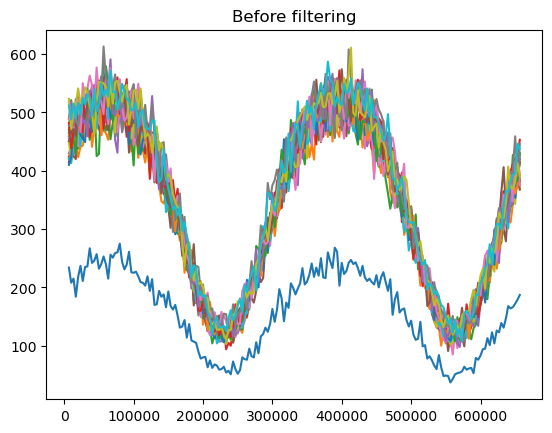

Text(0.5, 1.0, 'After filtering')

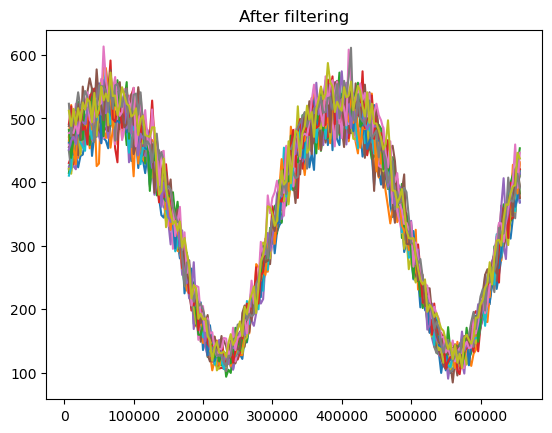

In [24]:
for el in p_list[9]["p_data"][2]["data"]:
    plt.plot(el[:,0], el[:,1])
plt.title("Before filtering")
plt.show()

def filter_list(original_list: list, elements_to_remove: list):
    filtered_list = [
        el for idx, el in enumerate(original_list) if not (idx in elements_to_remove) 
    ]
    return filtered_list

p_list[9]["p_data"][2]["data"] = filter_list(p_list[9]["p_data"][2]["data"], [0])

for el in p_list[9]["p_data"][2]["data"]:
    plt.plot(el[:,0], el[:,1])
plt.title("After filtering")
# plt.show()

### Plot all

In [25]:
# time_domain_visual_verification(p_list, rows, cols, 
#                                 particles_off=[i for i in range(num_particles) if i != 9]
#                                 )

## Get mean phases and errors

In [26]:
#Calculate list of phasors for the laser and all measurements
for step in exc_data_npy:
  freq = step["freq"]
  step["fft_amp_list"] = []
  for meas_idx, meas in enumerate(step["data"]):
    _, amp = get_xf_yf_fund(meas[:,0], meas[:,1])
    step["fft_amp_list"].append(amp)

In [27]:
# Get mean phase and error for each particle and each step (freq) 
for step in exc_data_npy:
    freq = step["freq"]
    amp_list = step["fft_amp_list"]
    _, _, phase, phase_error = get_mean_amp_and_phase(amp_list)
    step["mean_fft_info"] = [freq, phase, phase_error]

In [28]:
#Calculate list of phasors for all particles and all measurements
for p in p_list:
  for step in p["p_data"]:
    freq = step["freq"]
    step["fft_amp_list"] = []
    for meas_idx, meas in enumerate(step["data"]):
      _, amp = get_xf_yf_fund(meas[:,0], meas[:,1])
      step["fft_amp_list"].append(amp)

In [29]:
# Get mean phase and error for each particle and each step (freq) 
for p in p_list:
    for step in p["p_data"]:
        freq = step["freq"]
        amp_list = step["fft_amp_list"]
        _, _, phase, phase_error = get_mean_amp_and_phase(amp_list)
        step["mean_fft_info"] = [freq, phase, phase_error]

## Comparison — all particles

In [30]:
def get_error_bar(exc_data, p_list):
    exc_mean_phase = np.array([
            step["mean_fft_info"]
            #[freq, phase, phase_error]
            for step in exc_data
        ])
    error_exc = exc_mean_phase[:,2]
    # print(error_exc)

    for p in p_list:
        # if p["p_label"] !=1: continue
        p_mean_phase = np.array([
            step["mean_fft_info"]
            for step in p["p_data"]
            ])
        
        if (p_mean_phase[:,0]-exc_mean_phase[:,0]).sum() != 0.:
            print("Deu ruim!")
            return None
        else:
            pd_list = np.unwrap(p_mean_phase[:,1]-exc_mean_phase[:,1])
            pd_error = np.hypot(
                p_mean_phase[:,2],
                exc_mean_phase[:,2]
            )

        p["error_bar"] = np.column_stack((p_mean_phase[:,0], pd_list, pd_error))

get_error_bar(exc_data_npy, p_list)

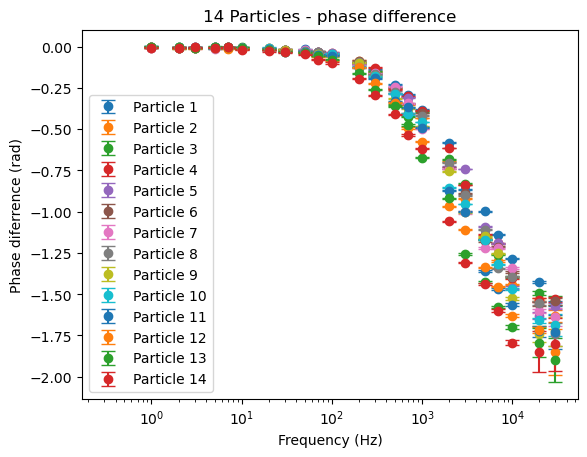

In [31]:
def plot_phase_difference(particles: list, p_to_skip = [], freqs_to_skip = []):
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for p_id, p in enumerate(particles):
        if p["p_label"] in p_to_skip: continue
        color = colors[p_id % len(colors)]
        # p["error_bar"]
        label_added = False
        for idx, error_point in enumerate(p["error_bar"]):
            # Skip frequencies larger than 20kHz
            if (error_point[0] in freqs_to_skip): 
                # print(f"Não foi calculado pra freq: {error_point[0]}Hz")
                continue
            
            current_label = f"Particle {p['p_label']}" if not label_added else None

            plt.errorbar(
                error_point[0],
                error_point[1],
                yerr=error_point[2],
                label=current_label,
                fmt='o',
                capsize=5,
                color=color,
            )
            label_added = True
        # plt.title(f"Particle {p['p_label']}  - phase difference")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Phase diferrence (rad)")
        plt.xscale("log")
    
    if len(particles)>1:
        plt_title = f"{len(particles)} Particles - phase difference" 
    else:
        plt_title = f"{len(particles)} Particle - phase difference" 

    plt.title(plt_title)
    plt.legend()
    plt.show()

plot_phase_difference(p_list, p_to_skip=[], freqs_to_skip=[50000, 70000, 100000])

## Signal-Noise relation

### Harmonic Amplitudes

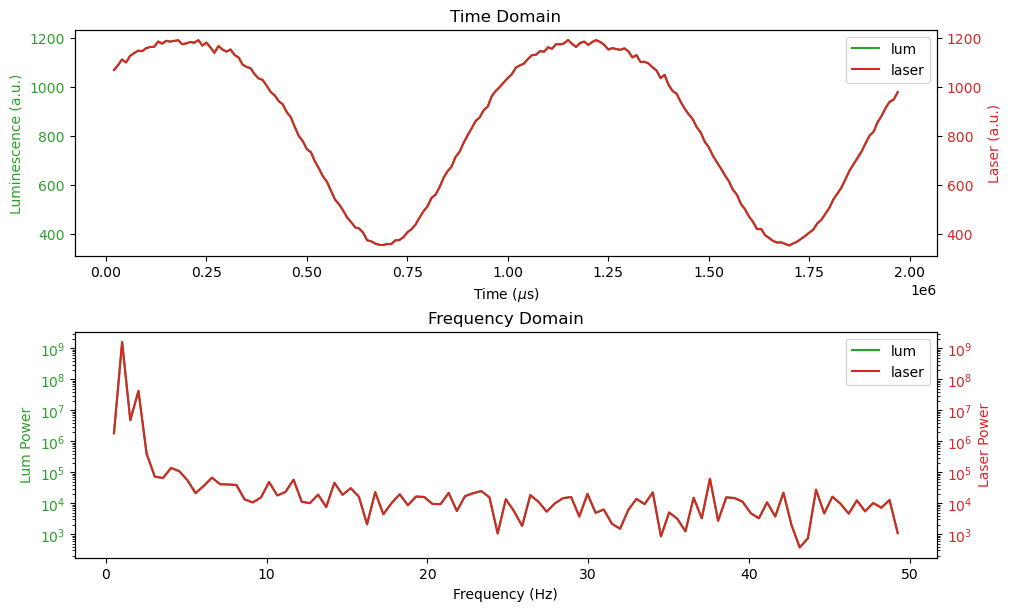

In [32]:
# Verificação visual da medida de 1Hz
for p_idx, p in enumerate(p_list):
    if p_idx != 0: continue

    for step_idx, step in enumerate(p["p_data"]):
        if step["freq"] != 1: continue

        time = np.array(step["data"])[0,:,0]
        signal = np.array(step["data"])[:,:,1].mean(axis=0)
        plot_time_and_freq_domain(time, signal, signal)

Nos gráficos abaixo, são mostrados as potências em função das frequências para os 20 primeiros harmônicos. 

A linha tracejada (verde para luminescência e cinza para o laser) representa o valor de $\mu +3\sigma$, onde $\mu$ é a média e $\sigma$ é o desvio padrão do conjunto $\{ P_k \}$ para $k \ge 20$.  

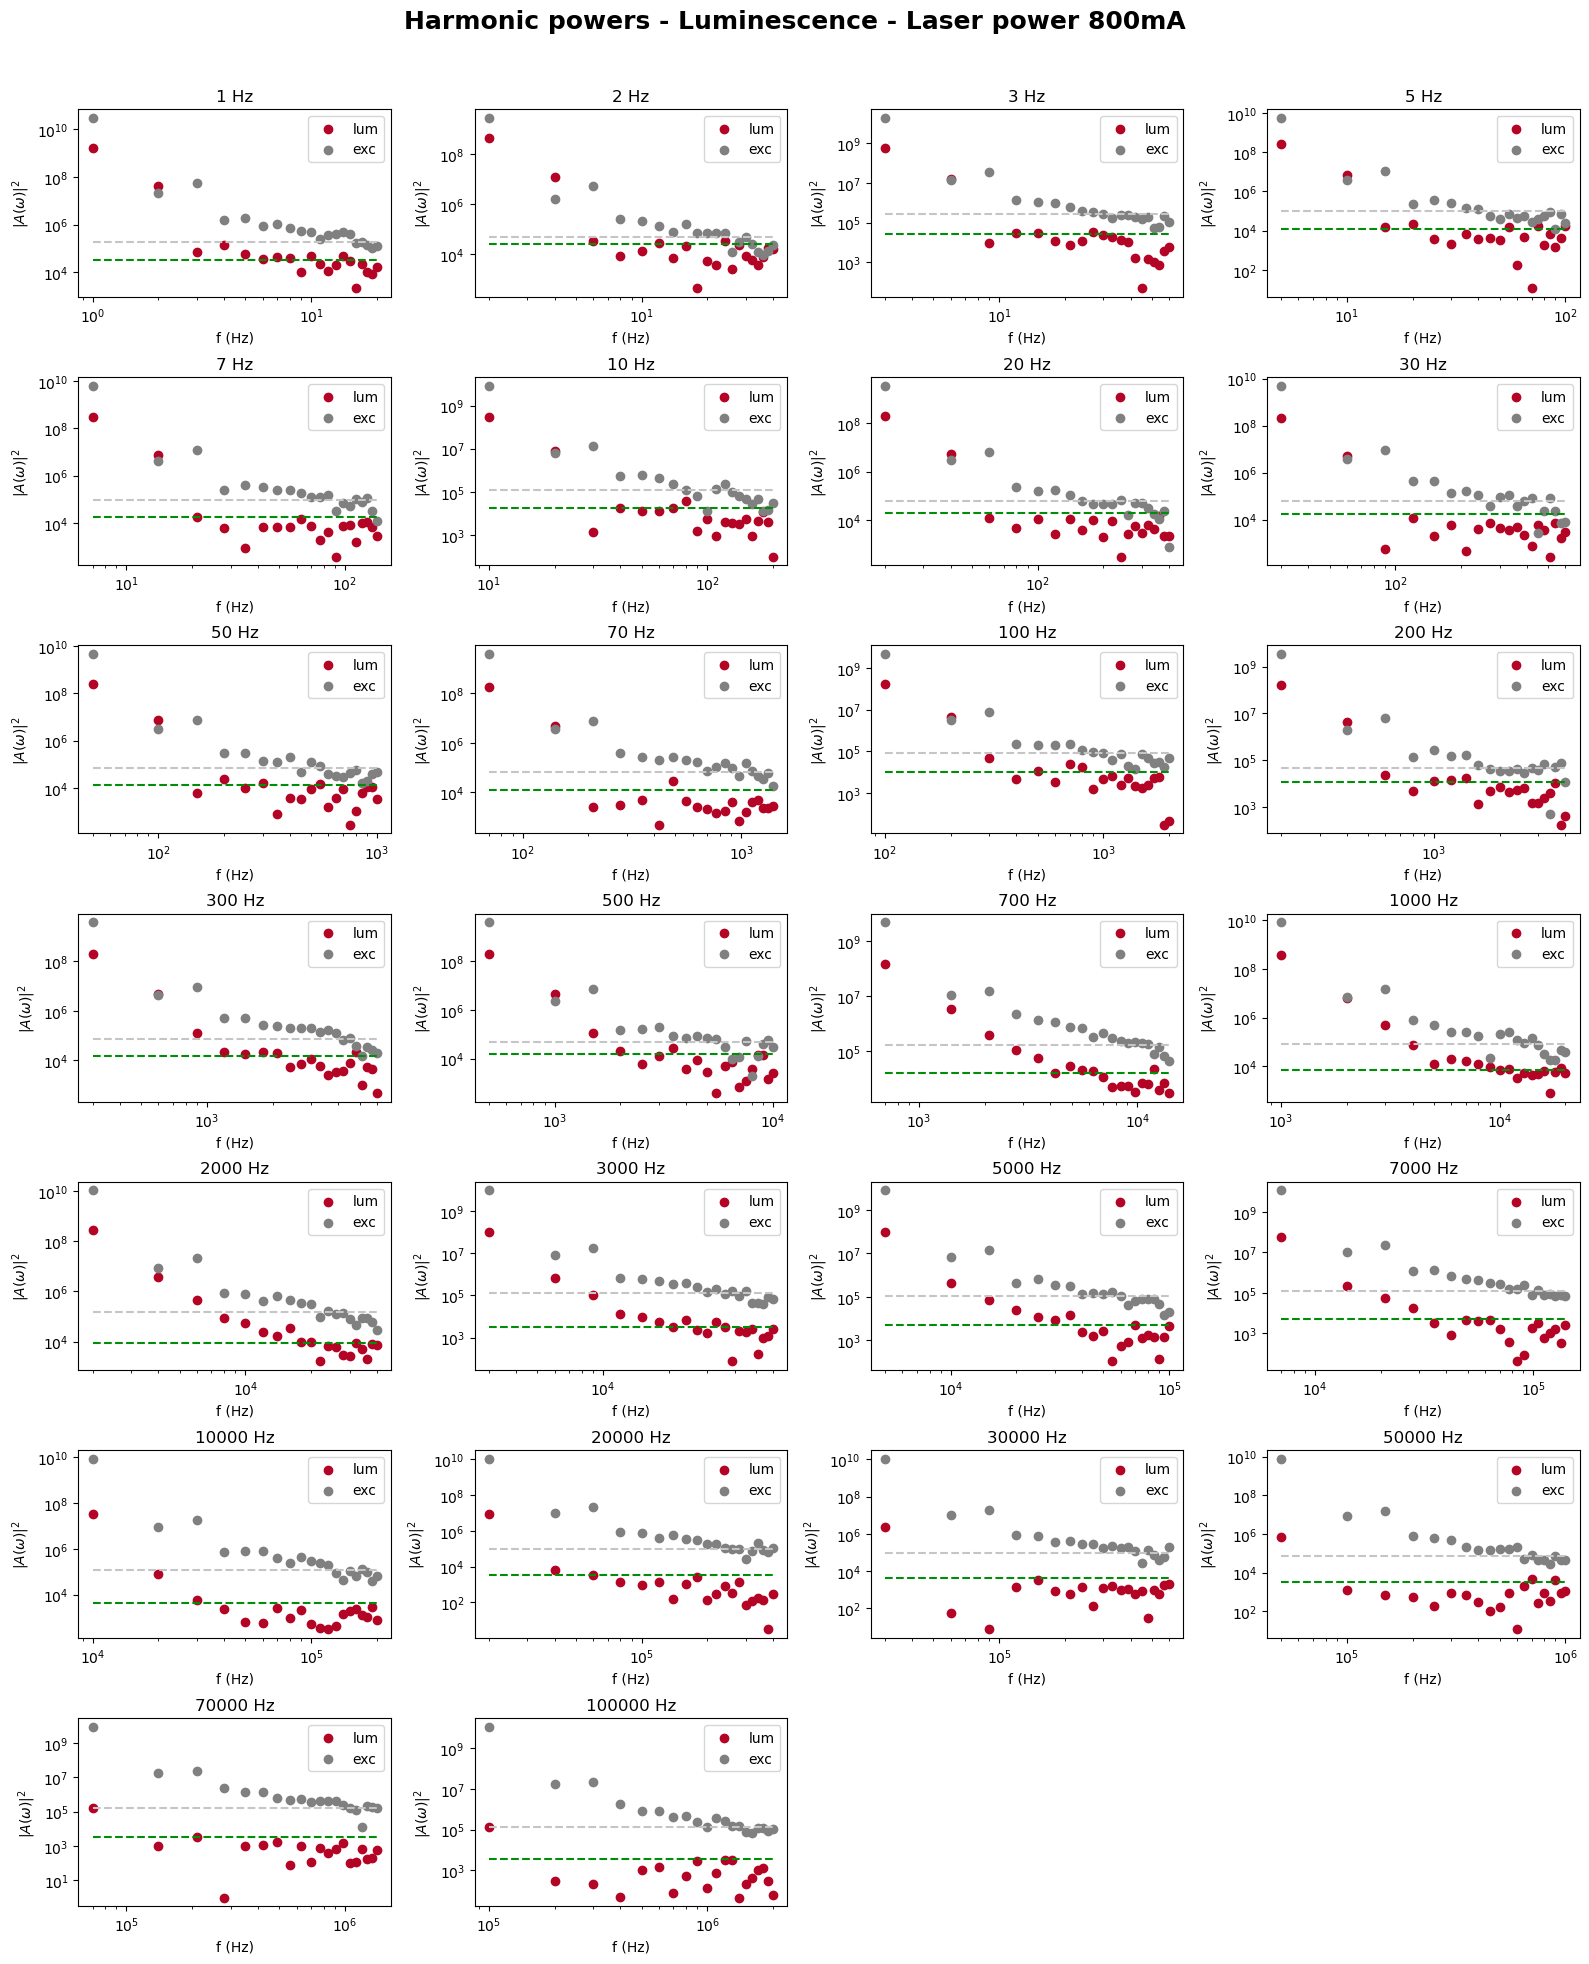

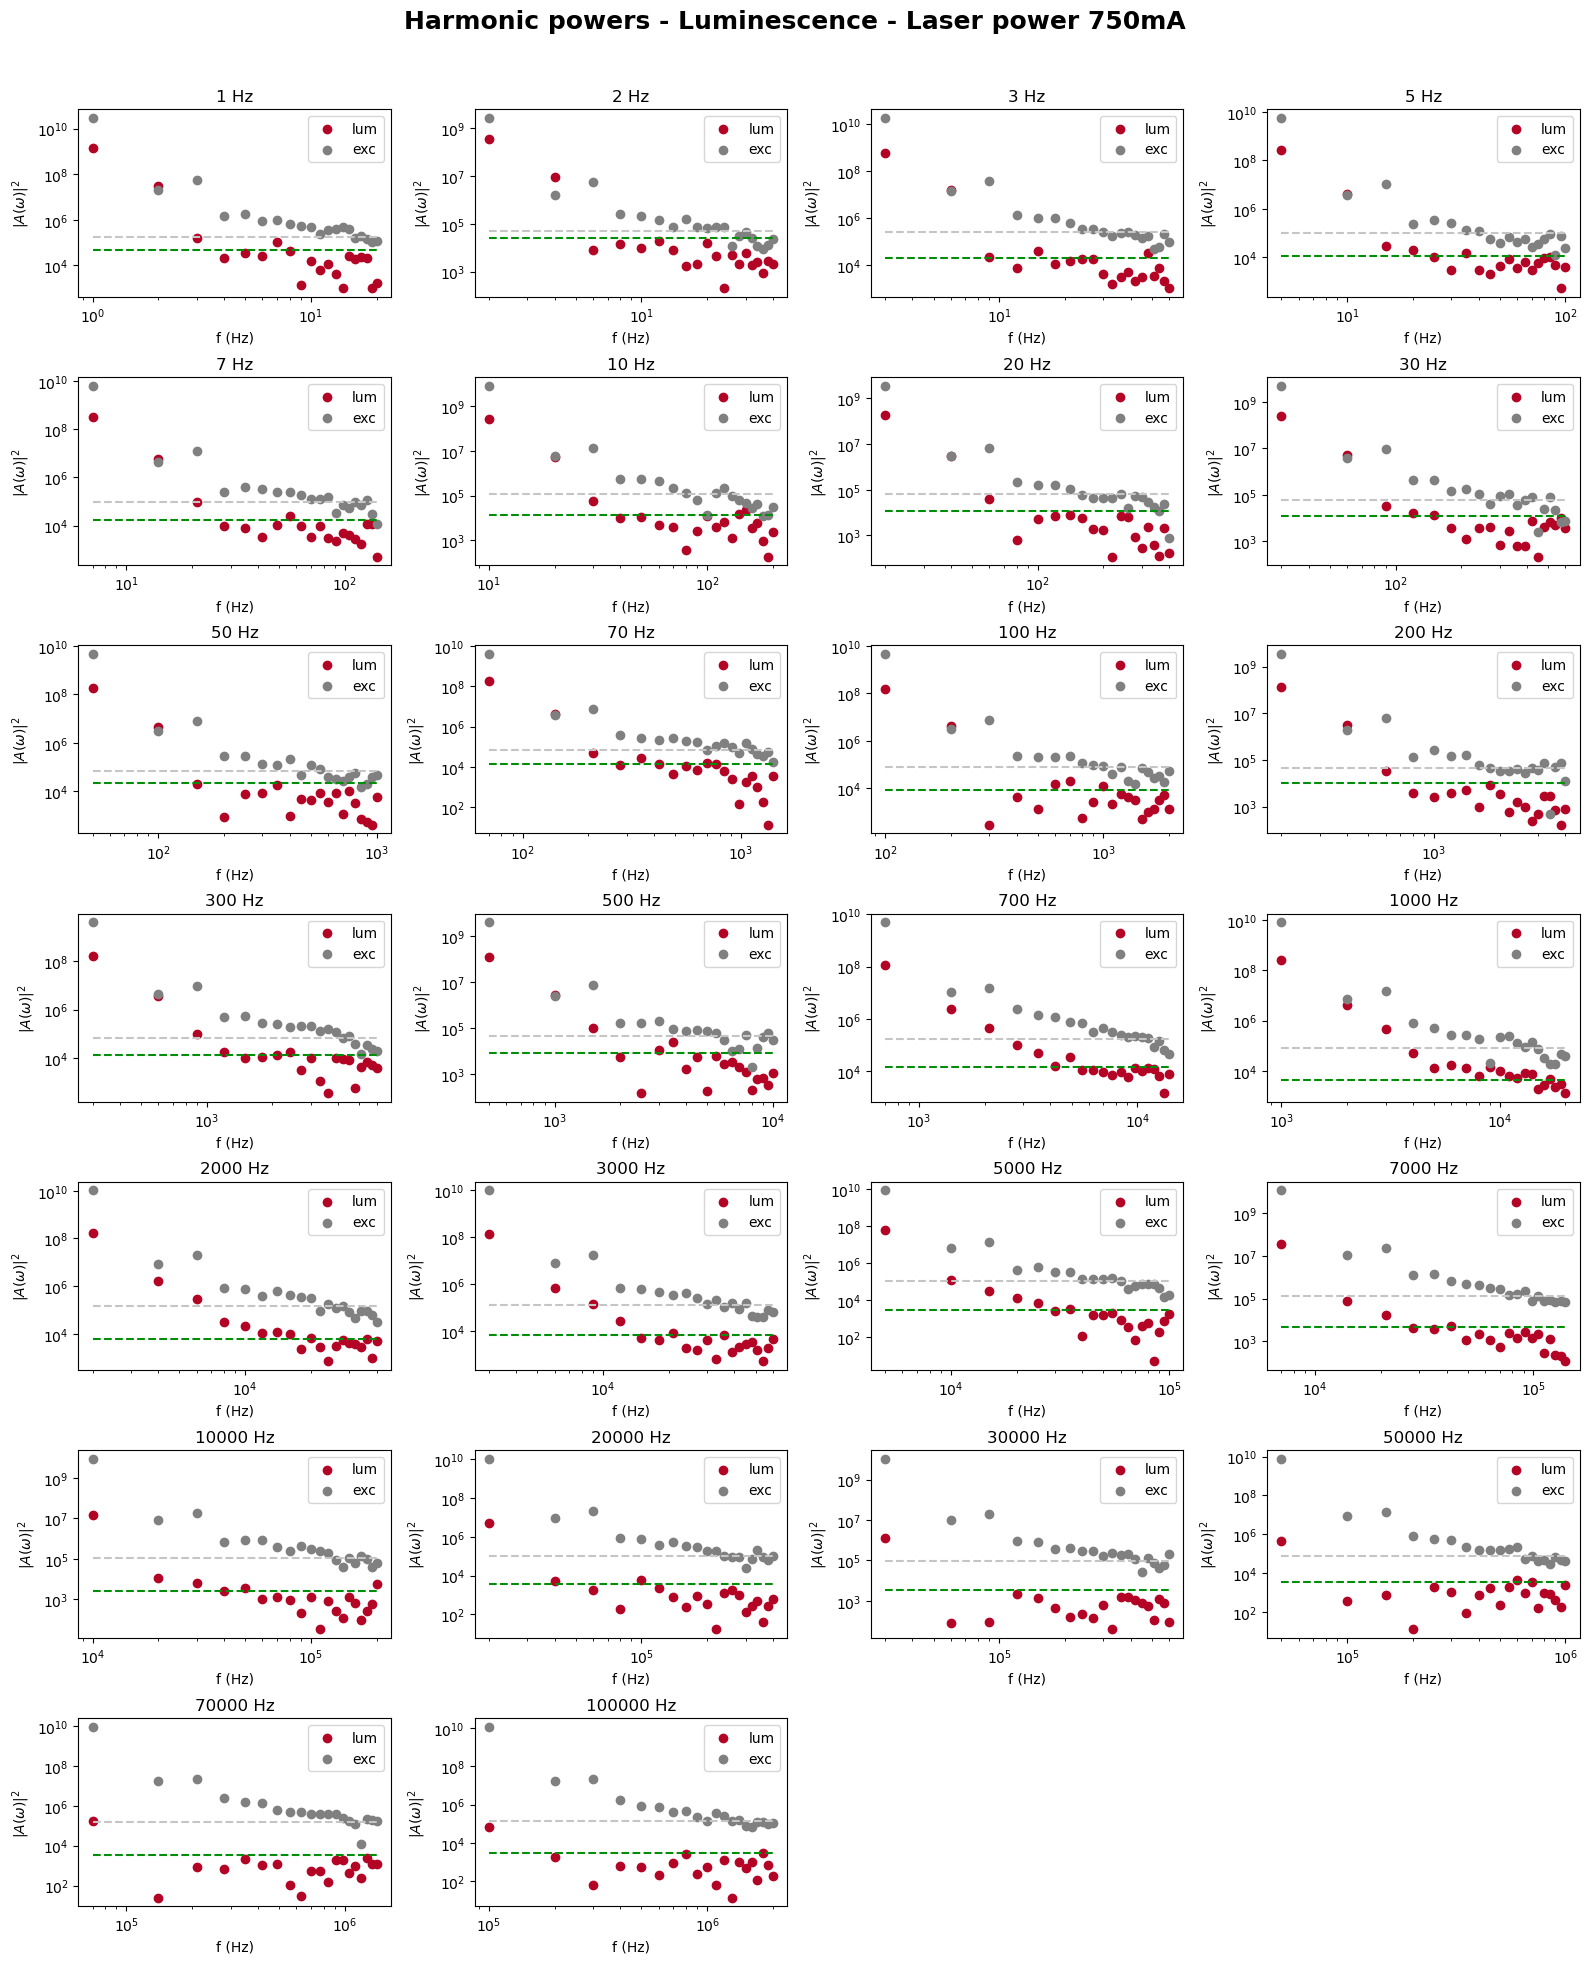

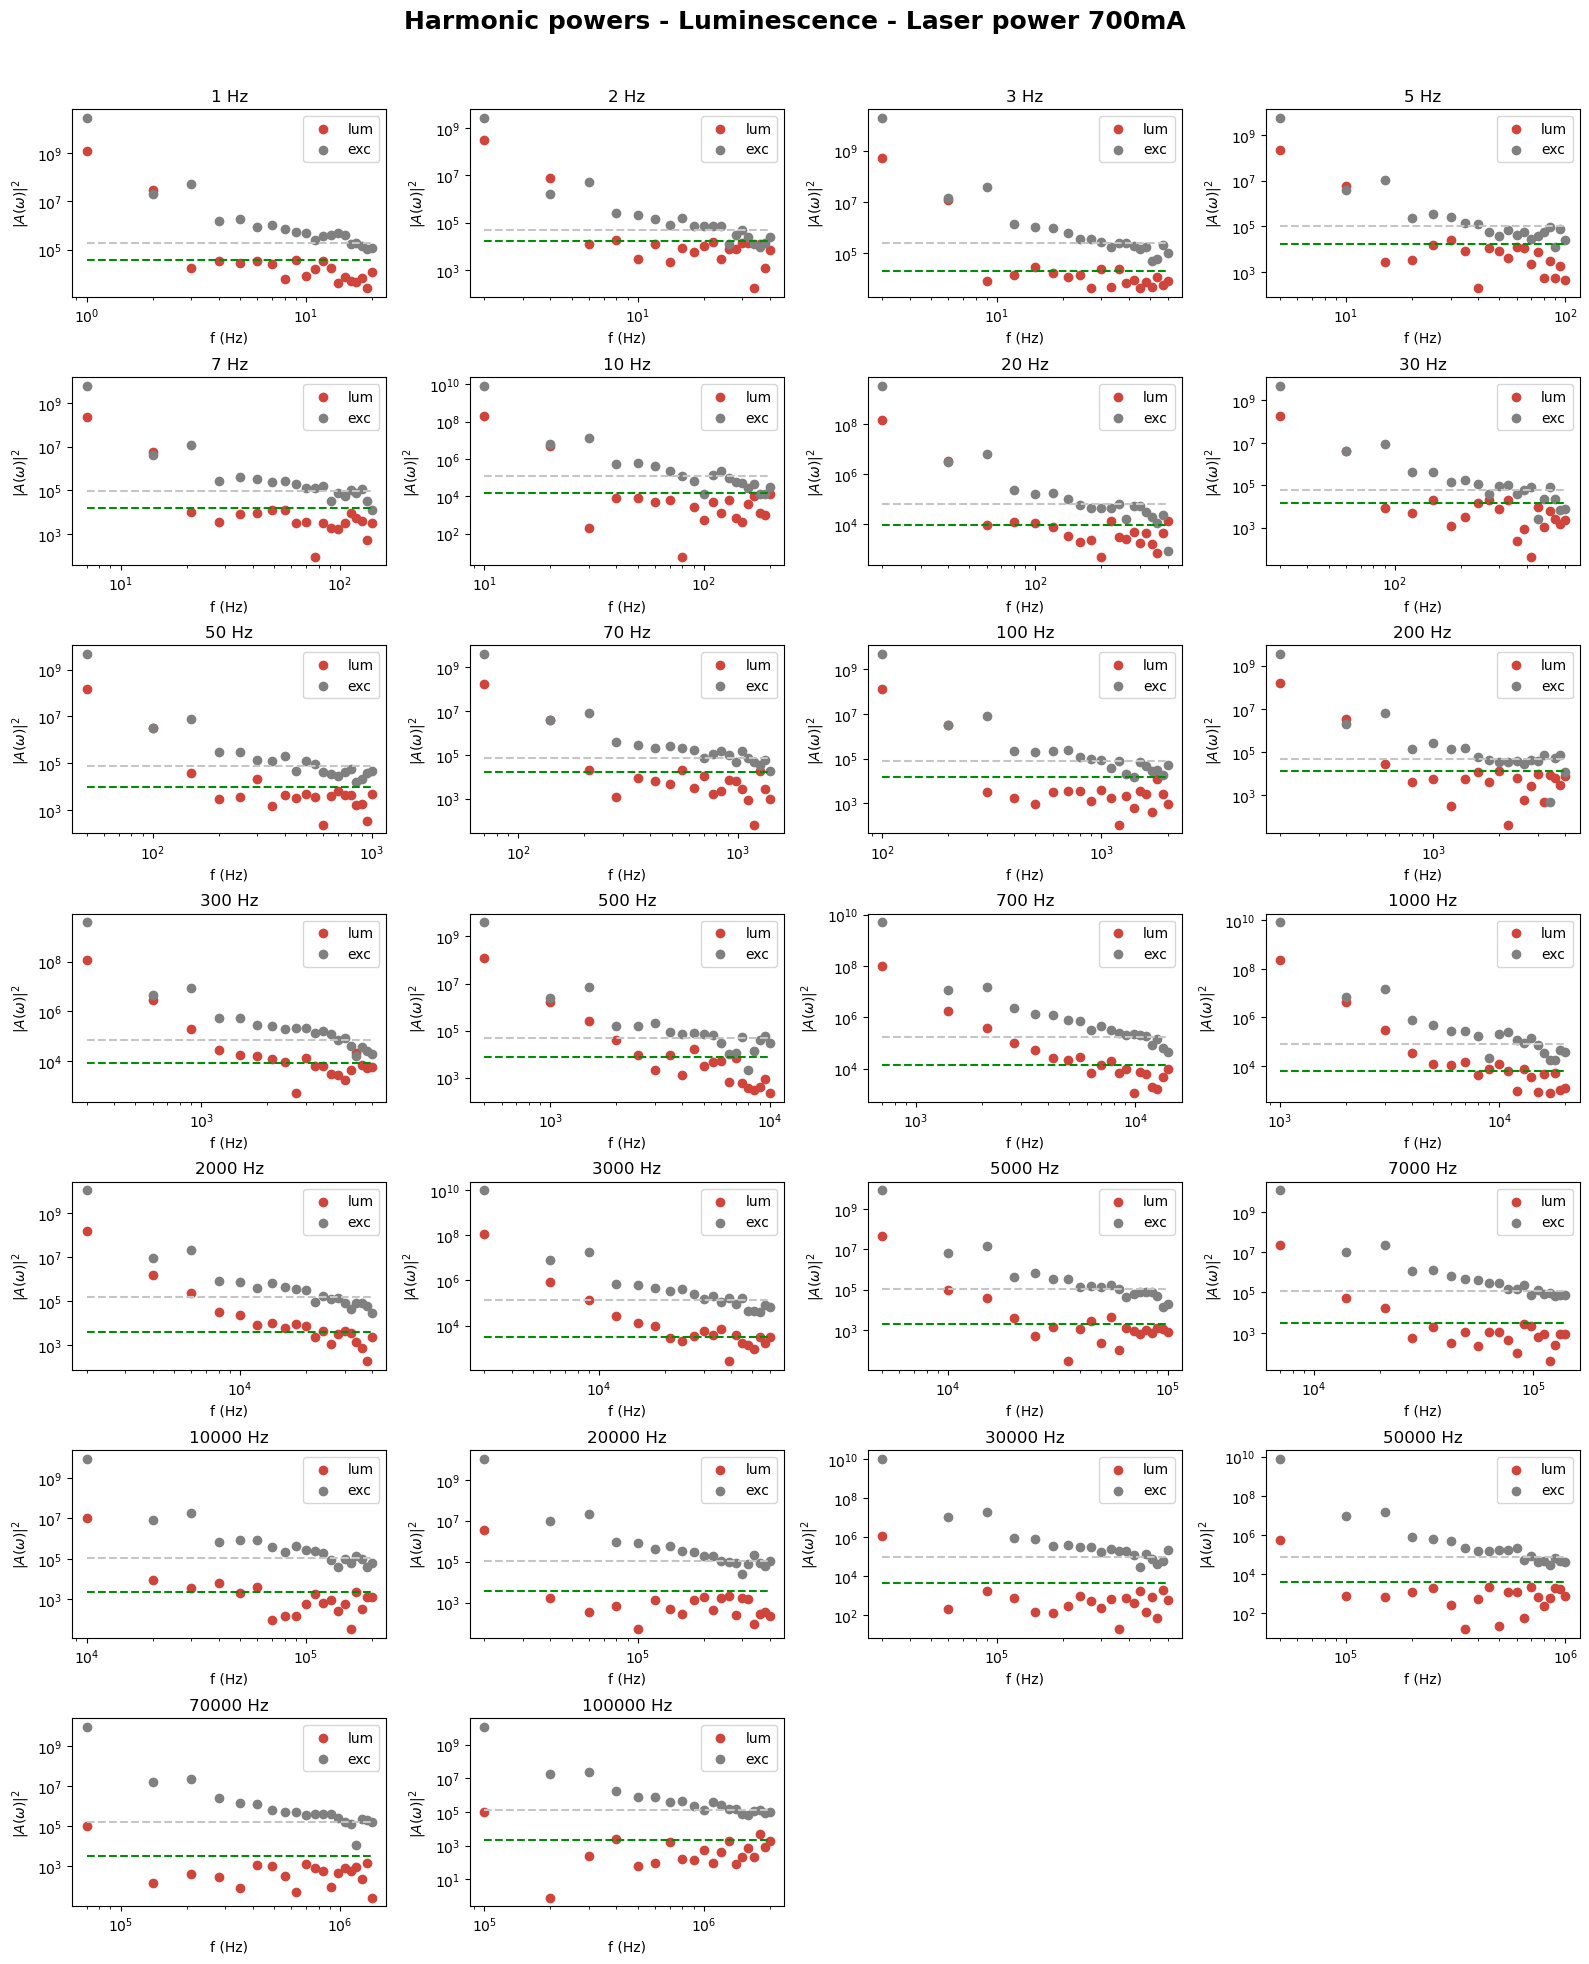

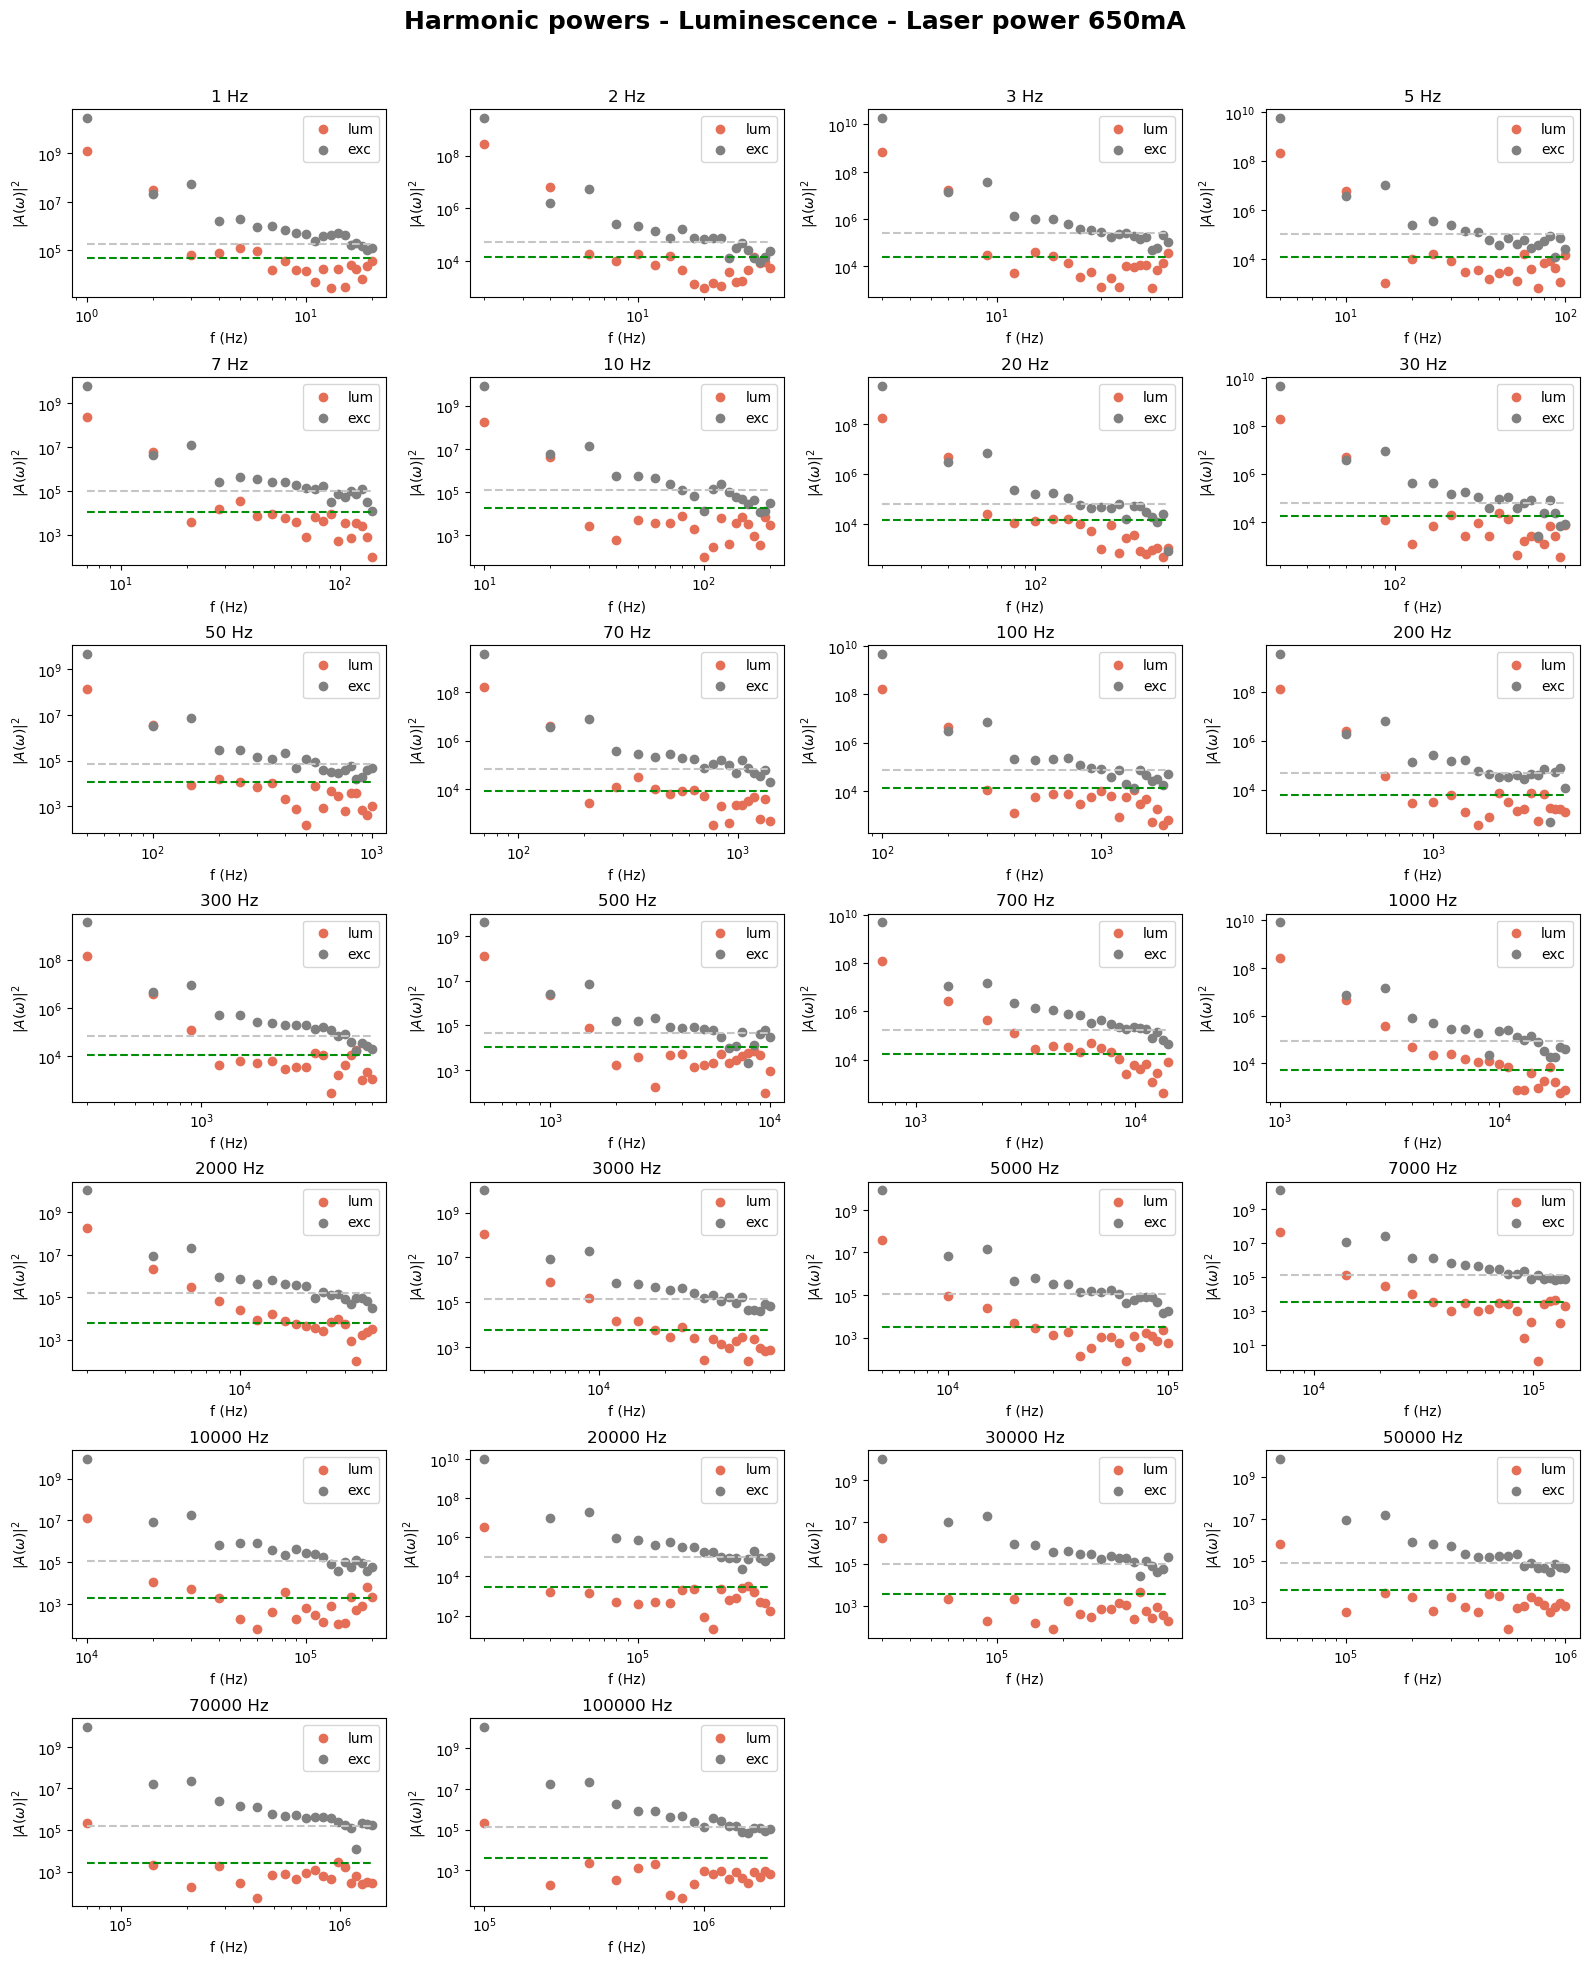

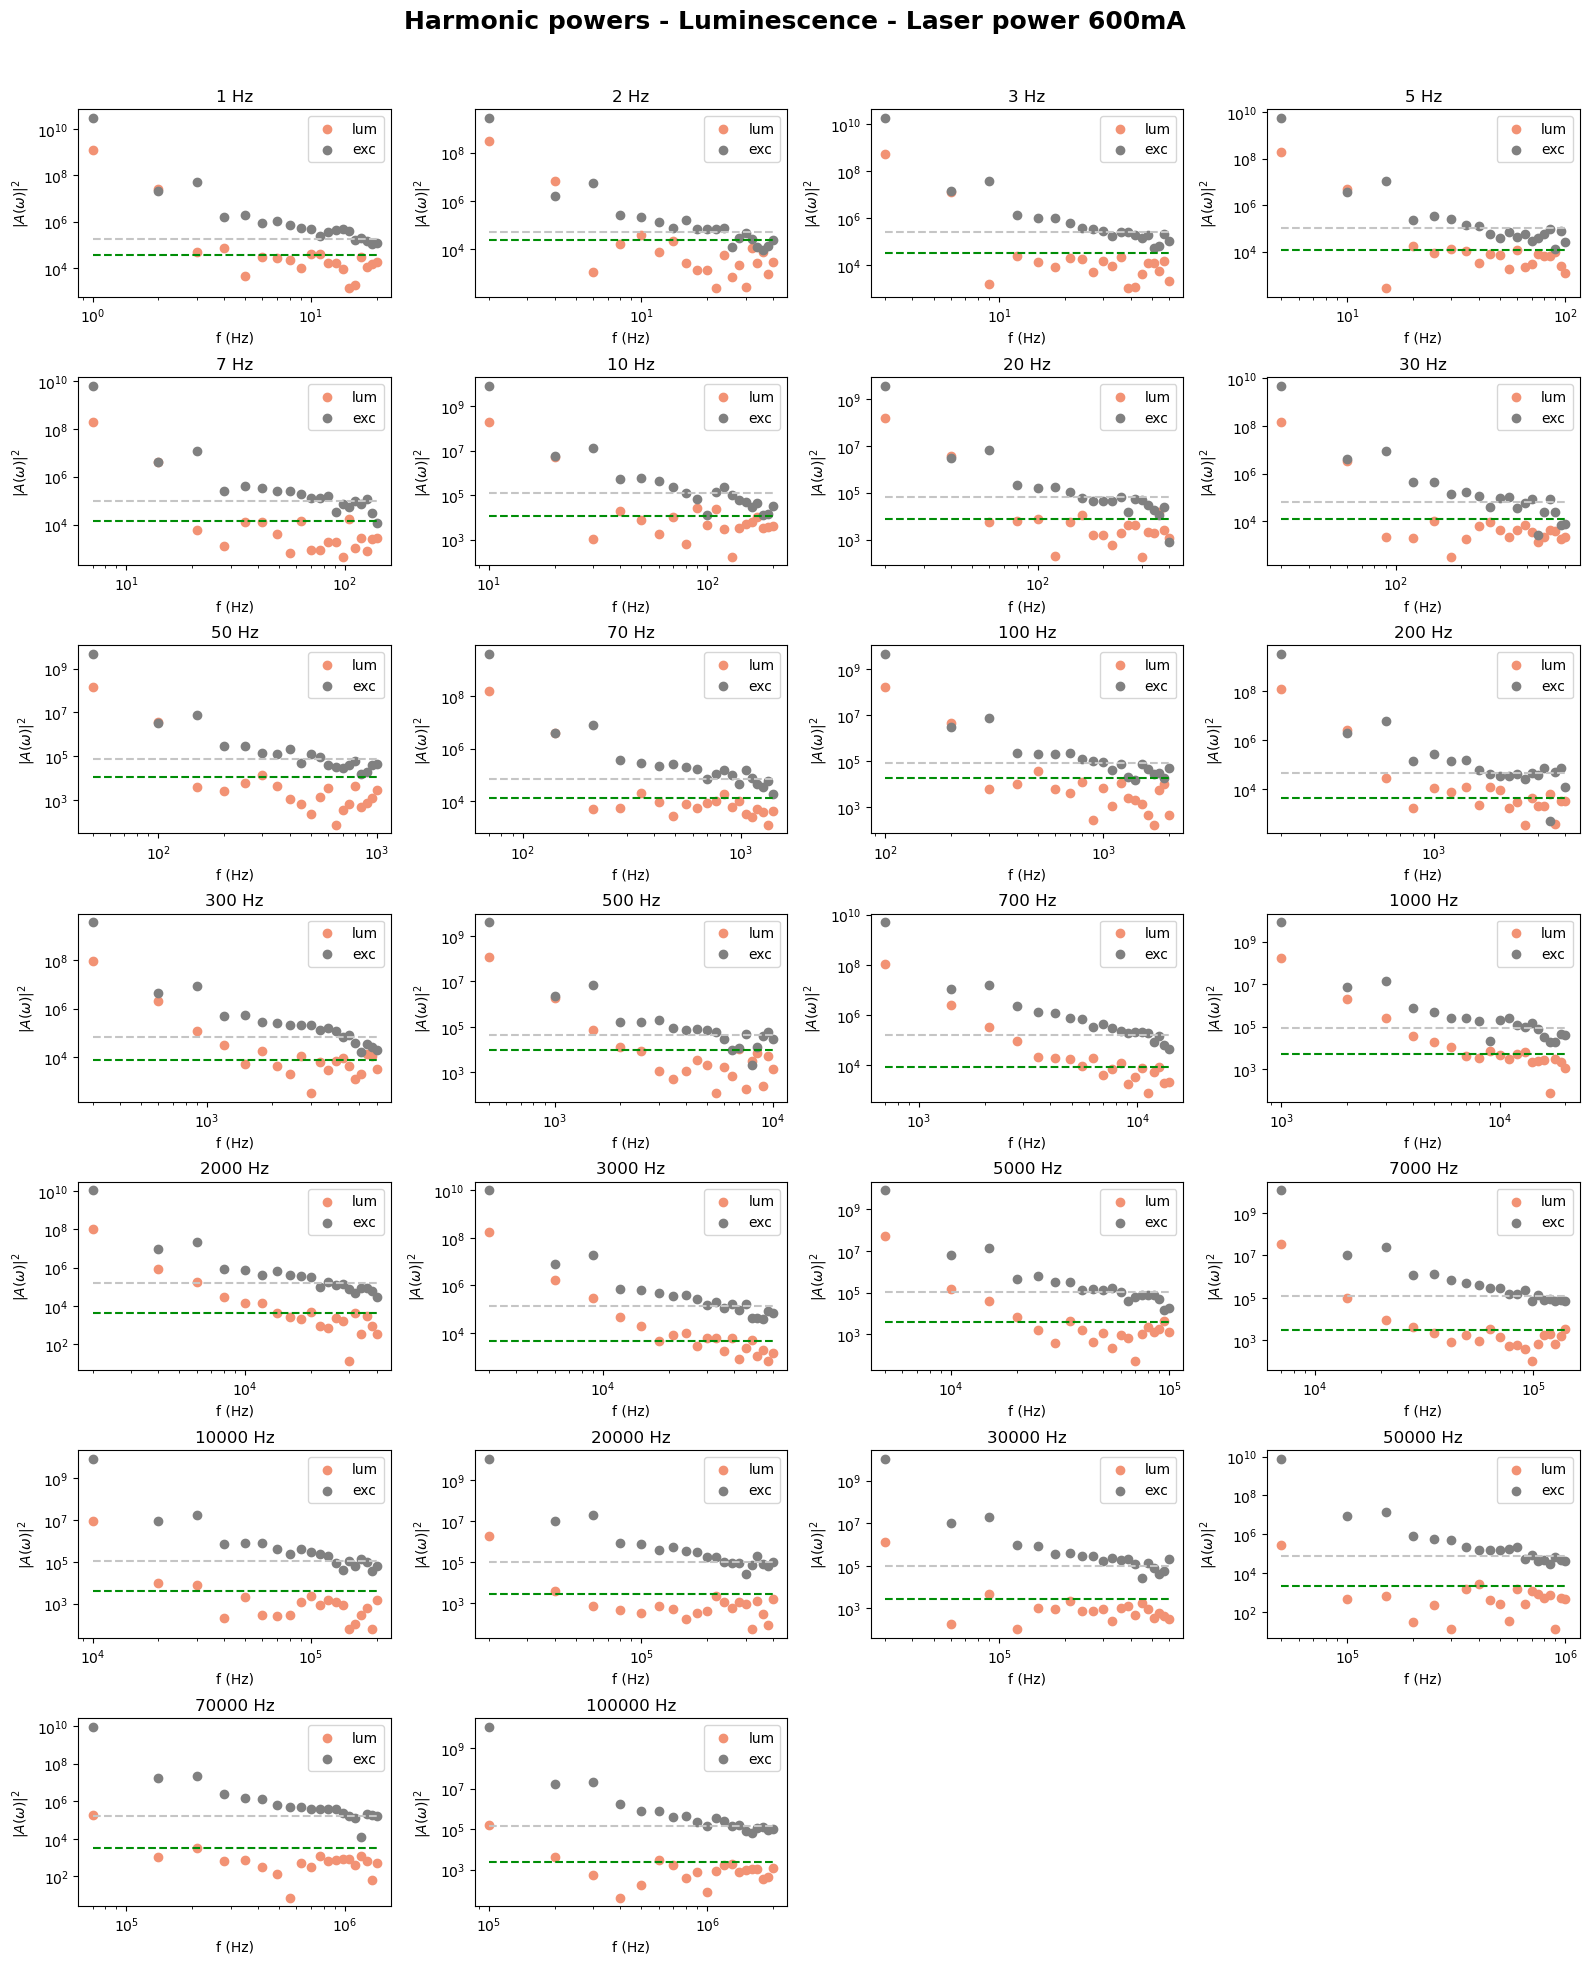

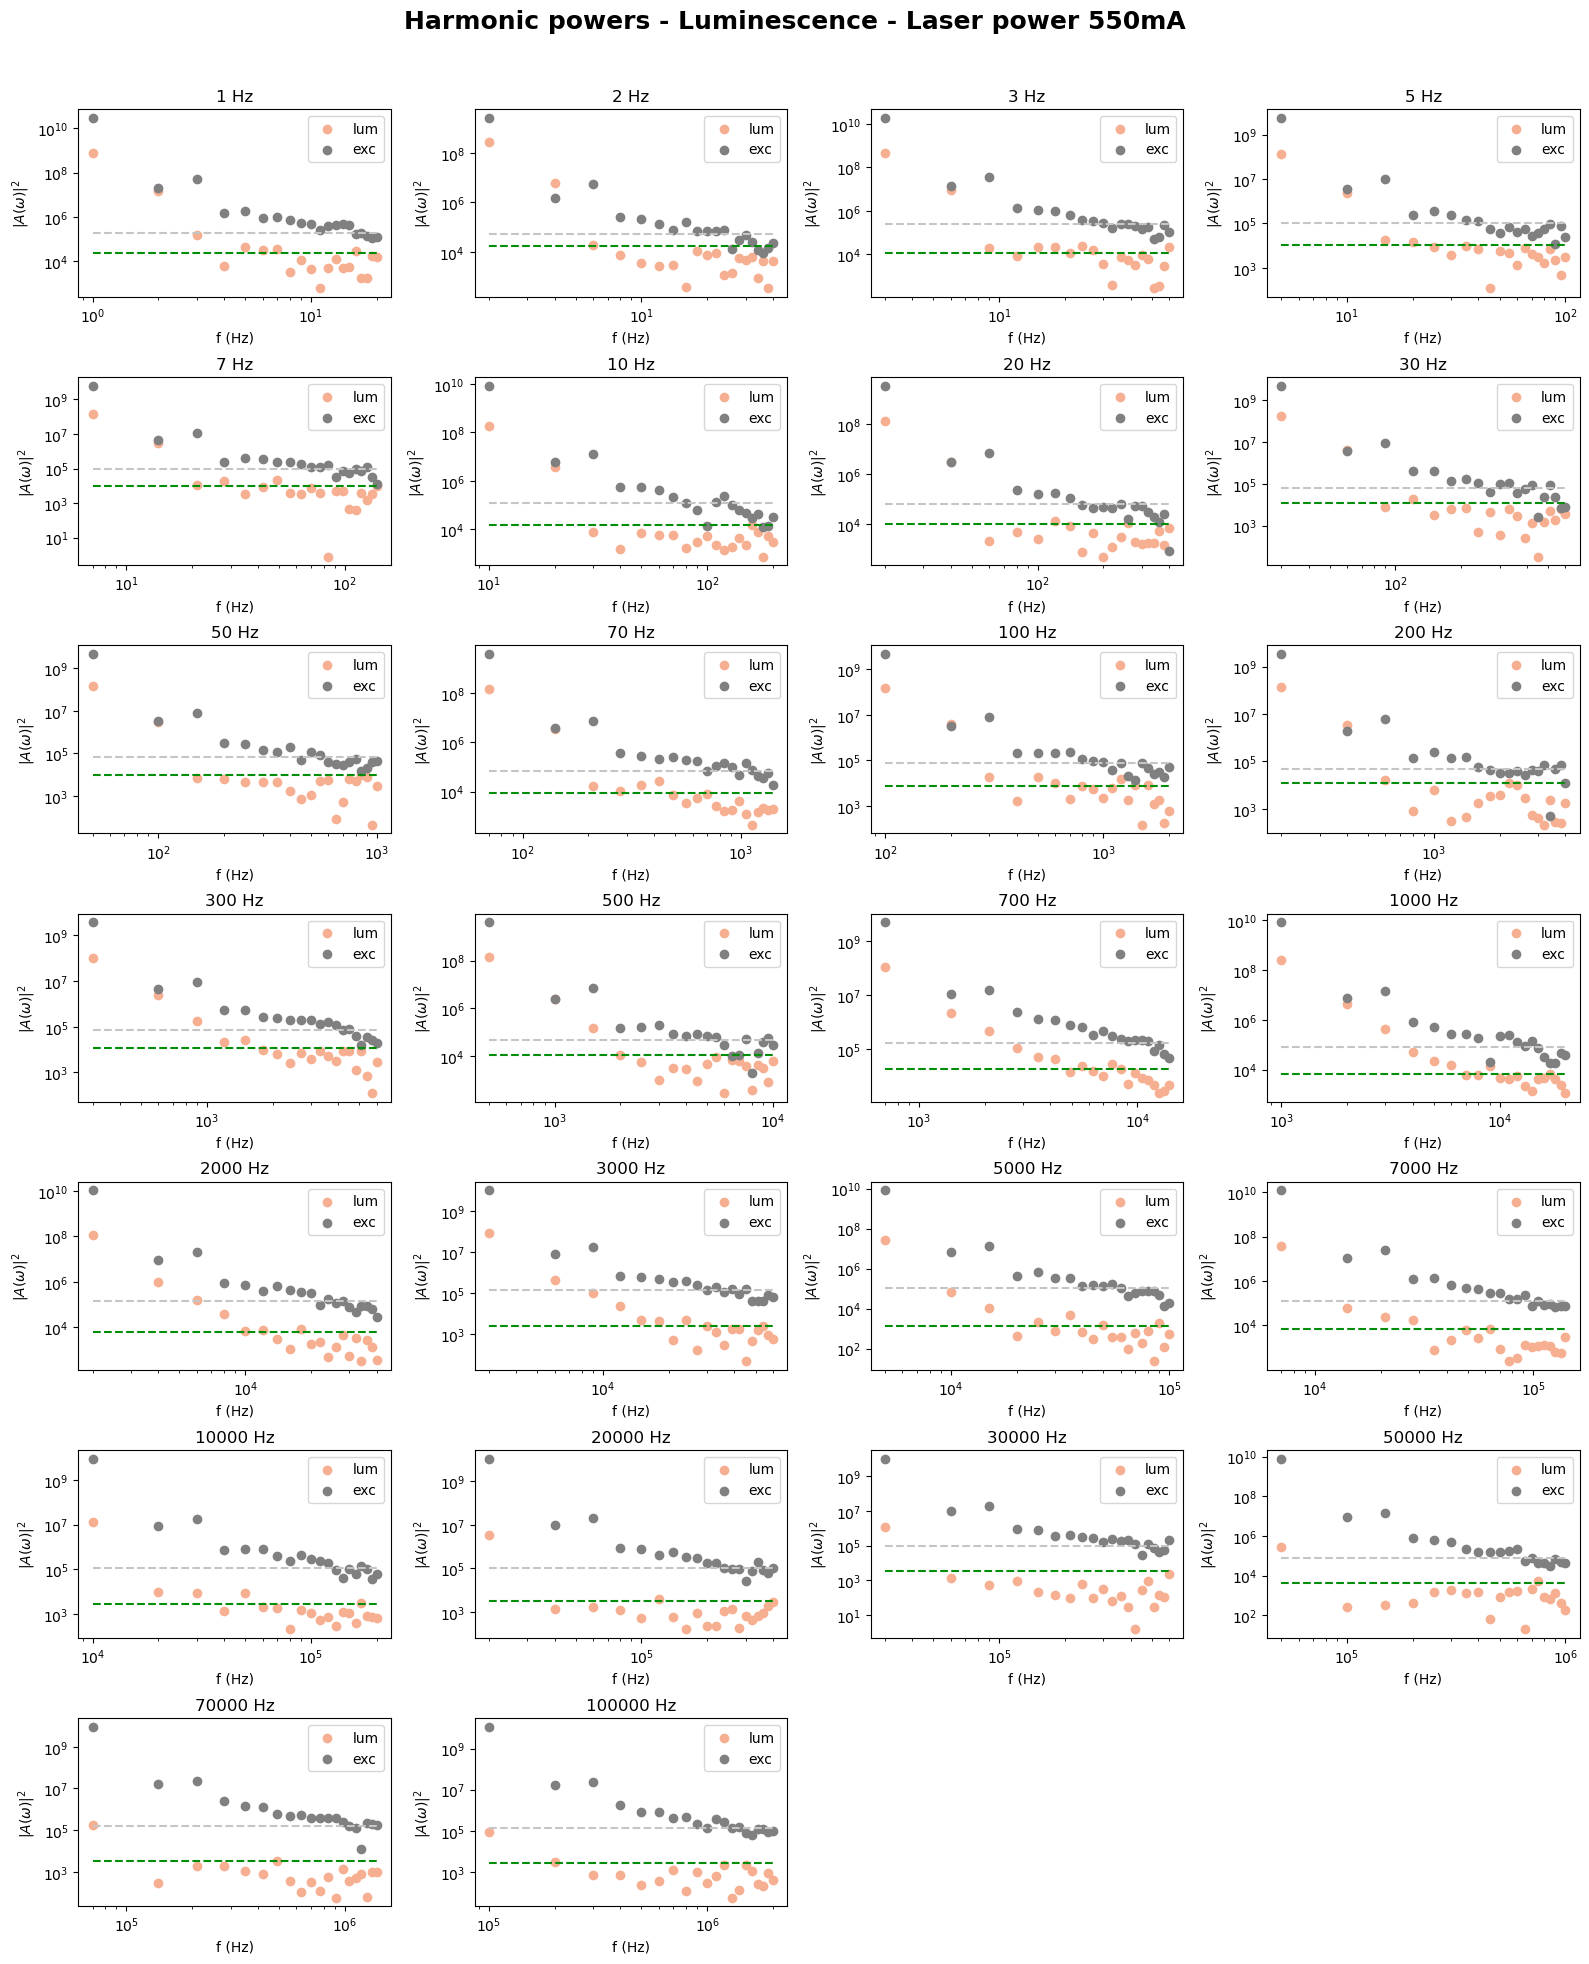

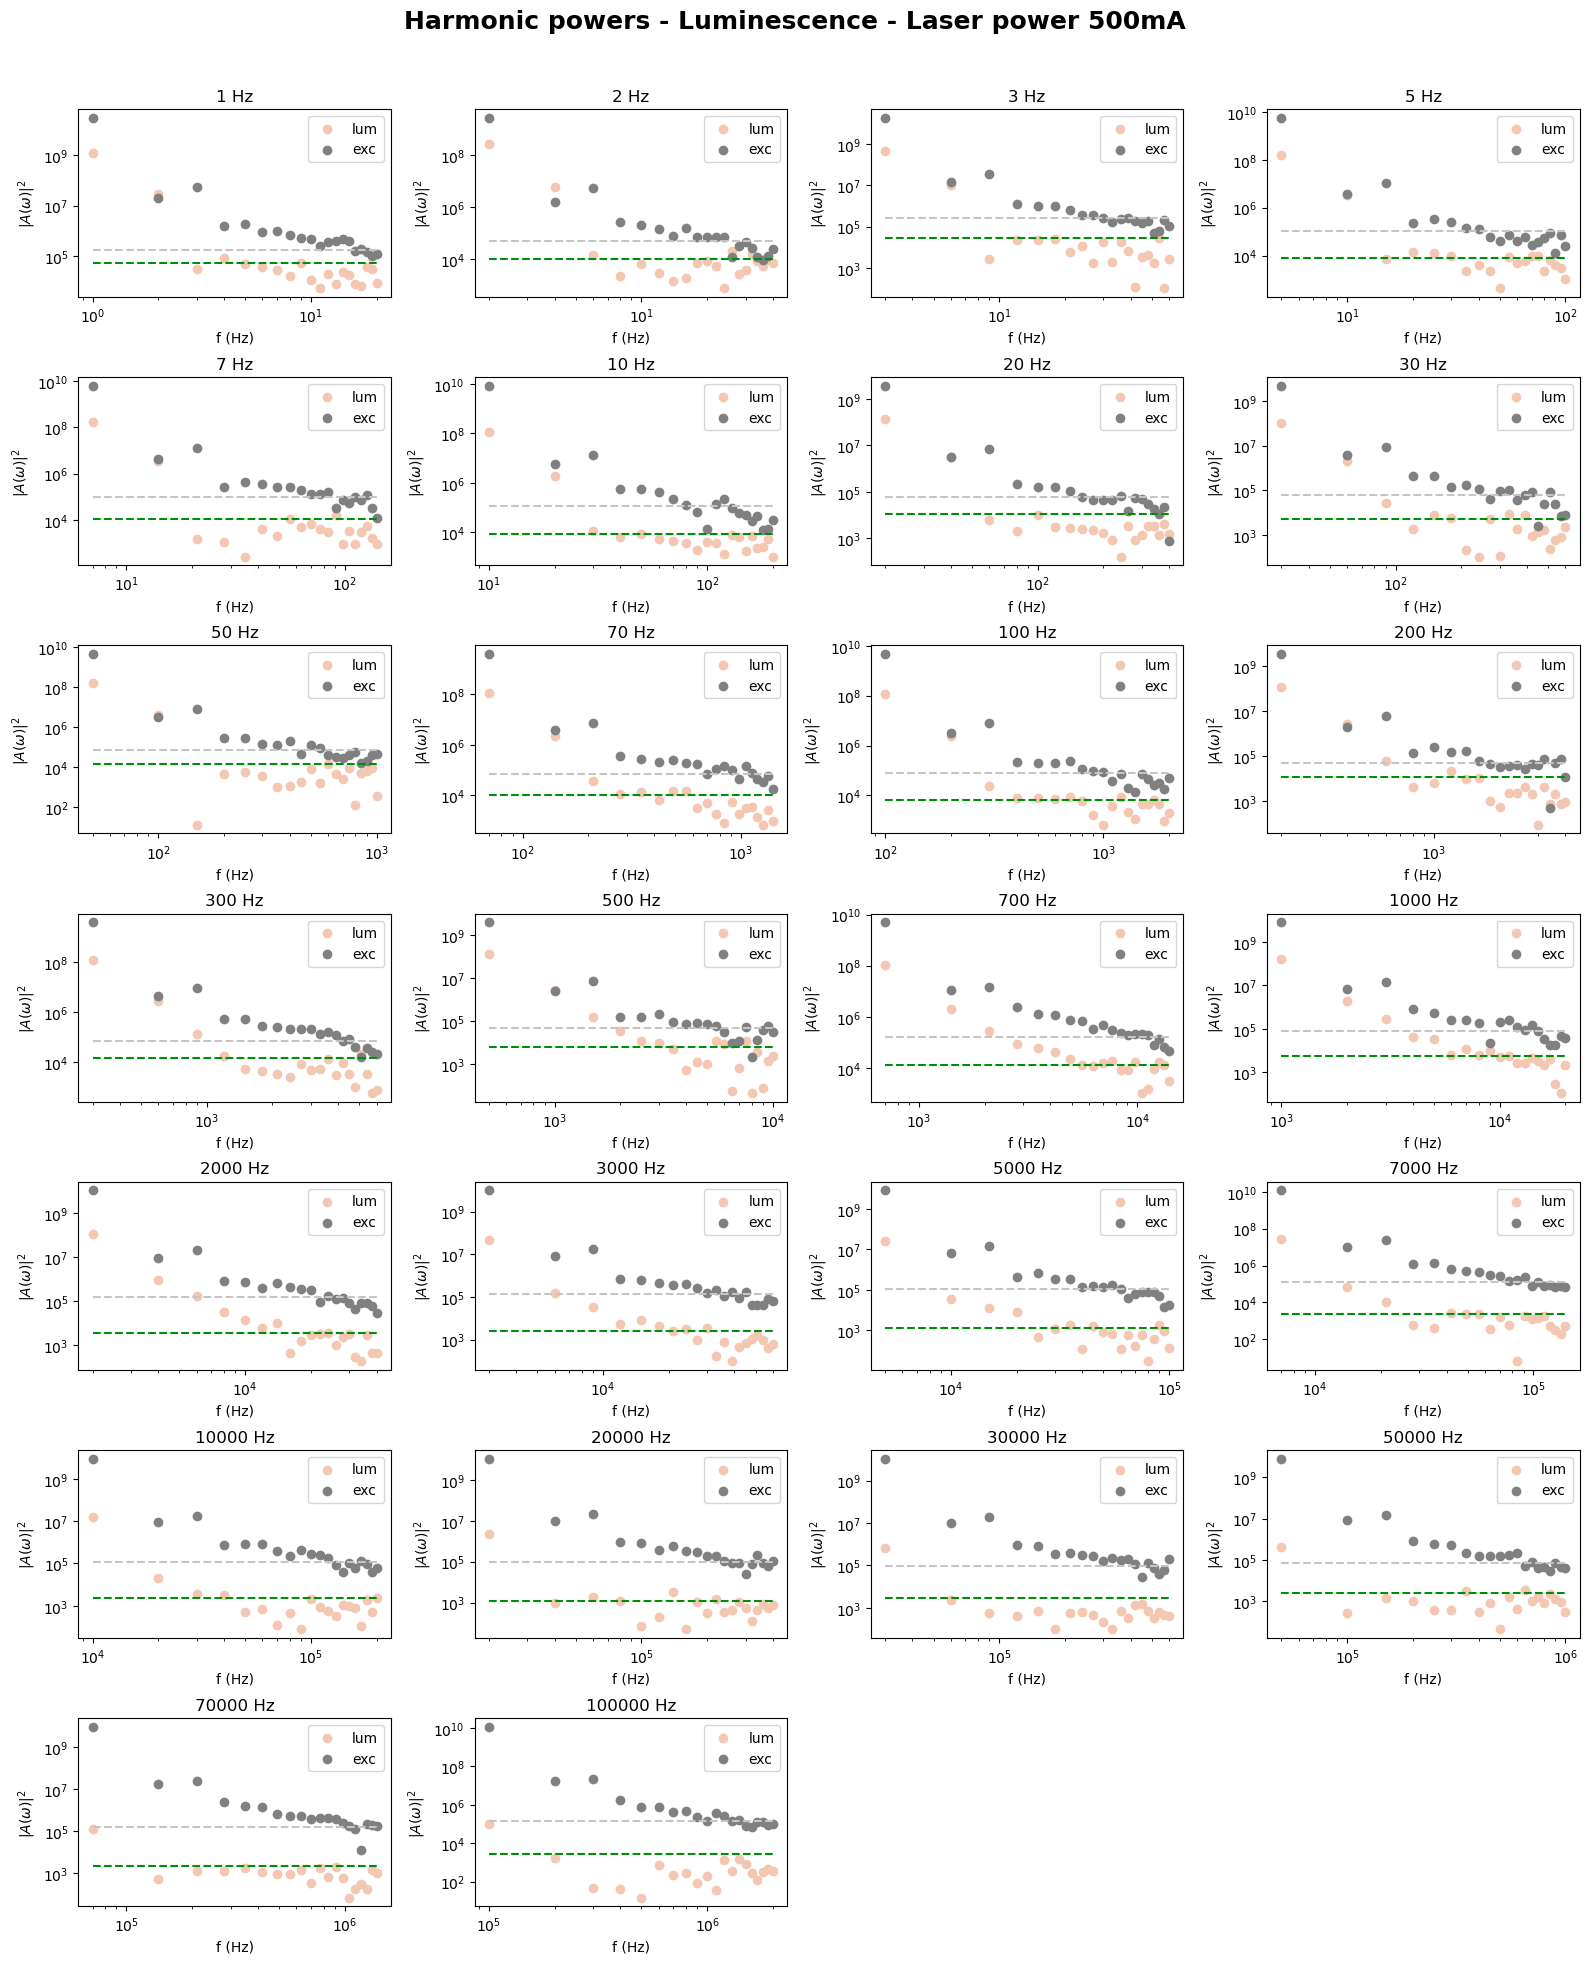

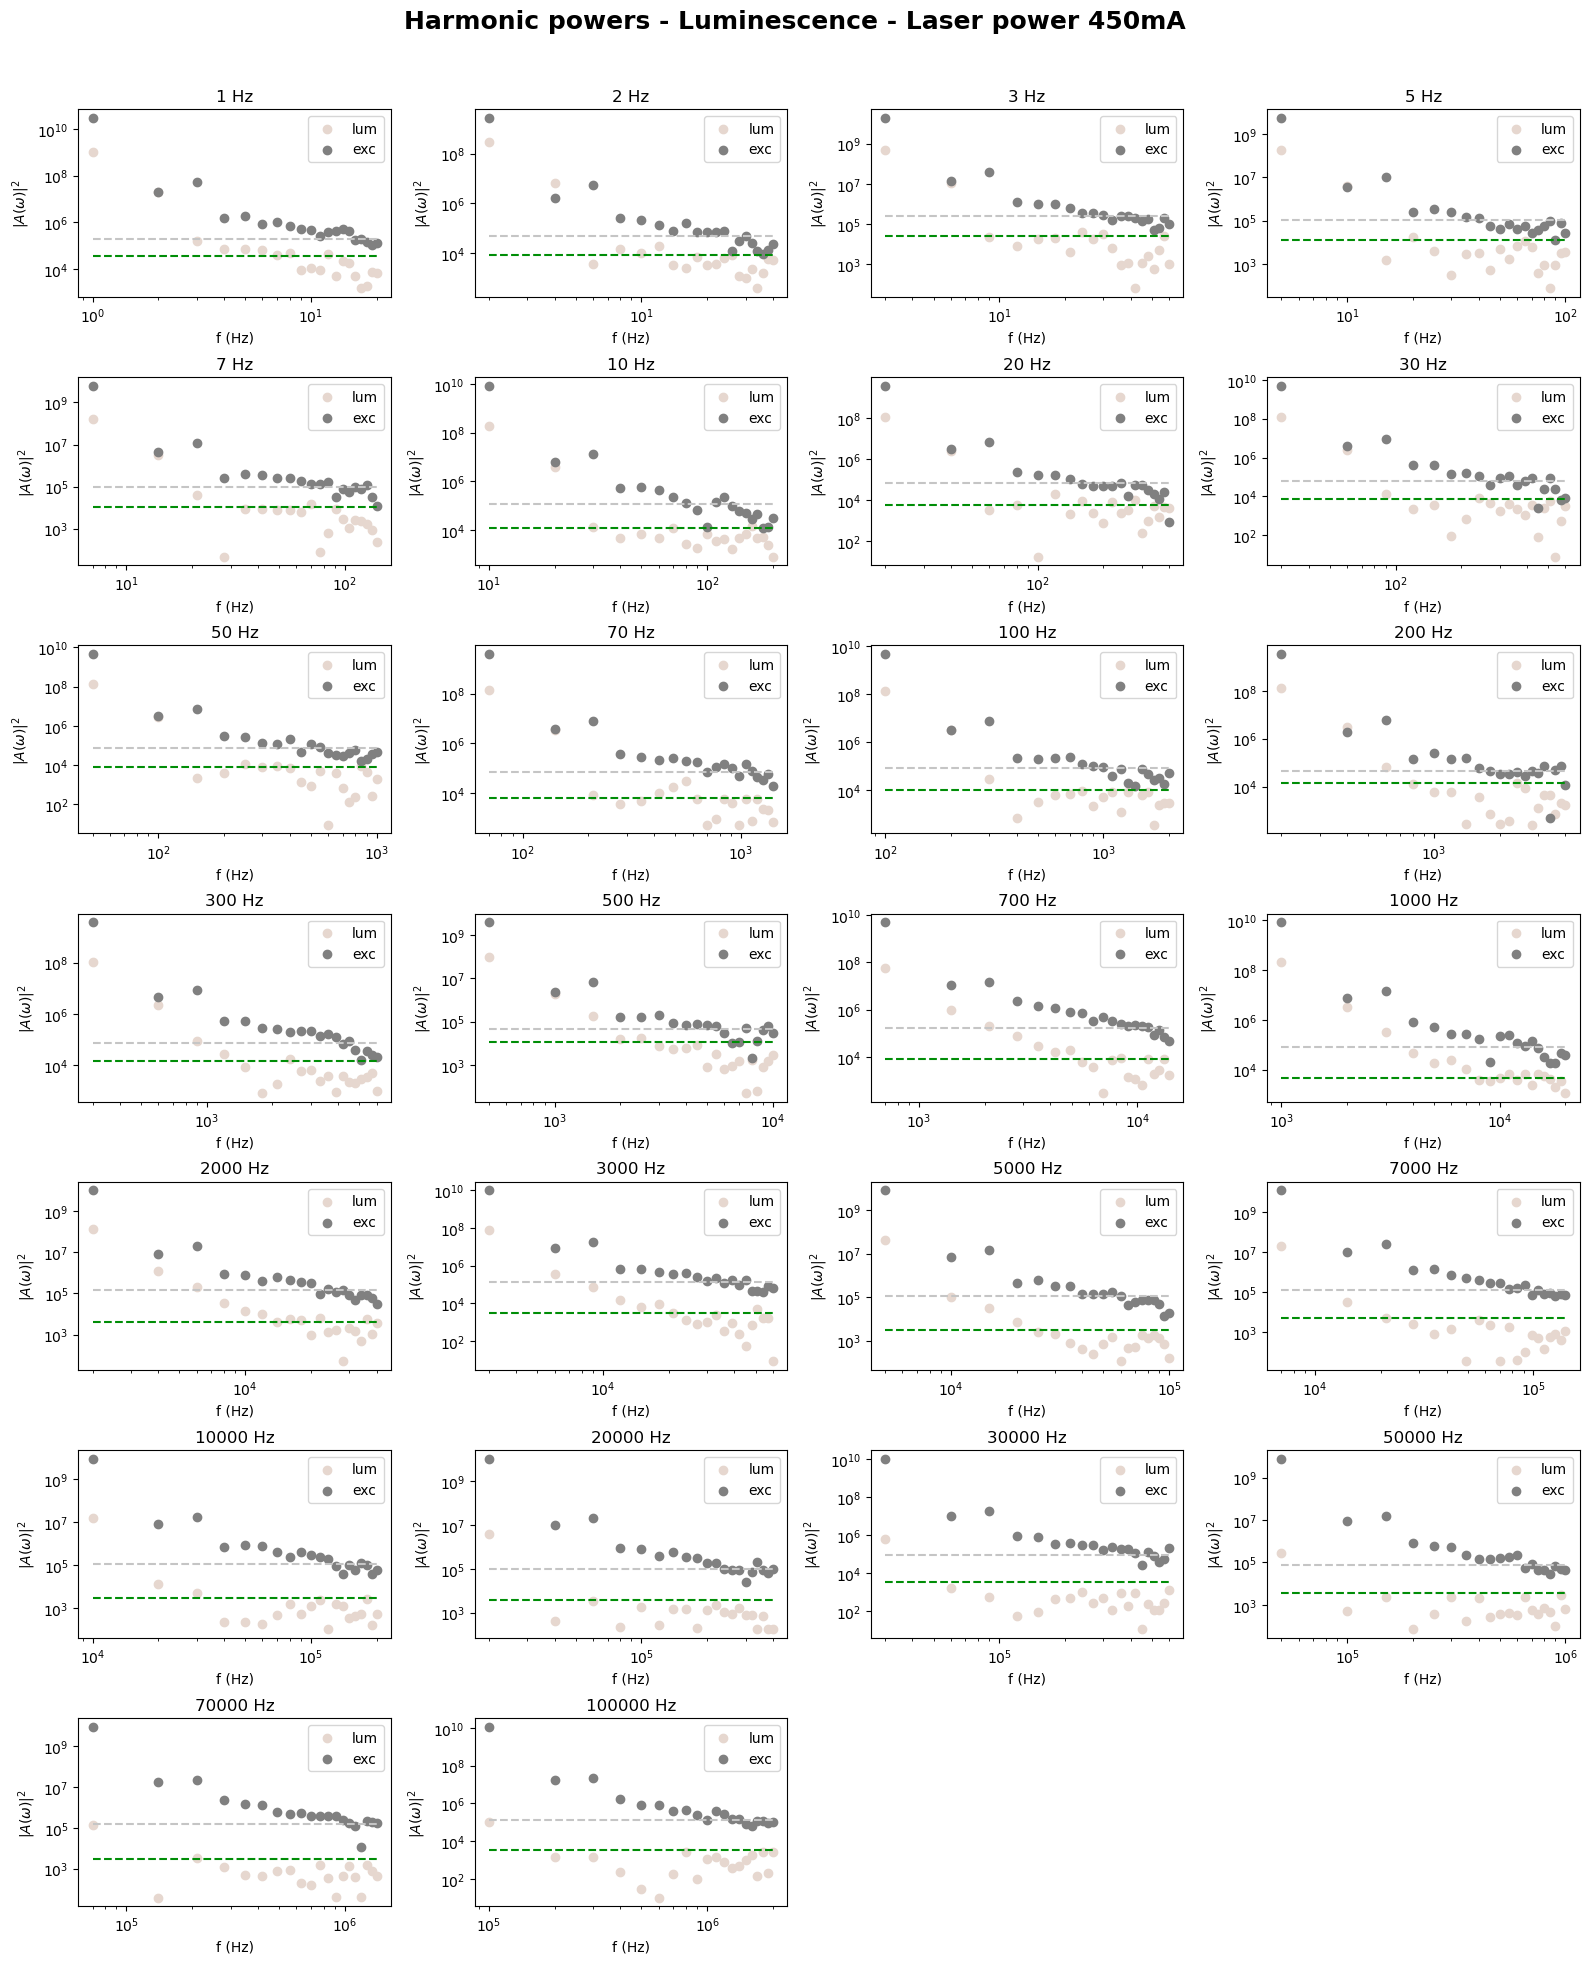

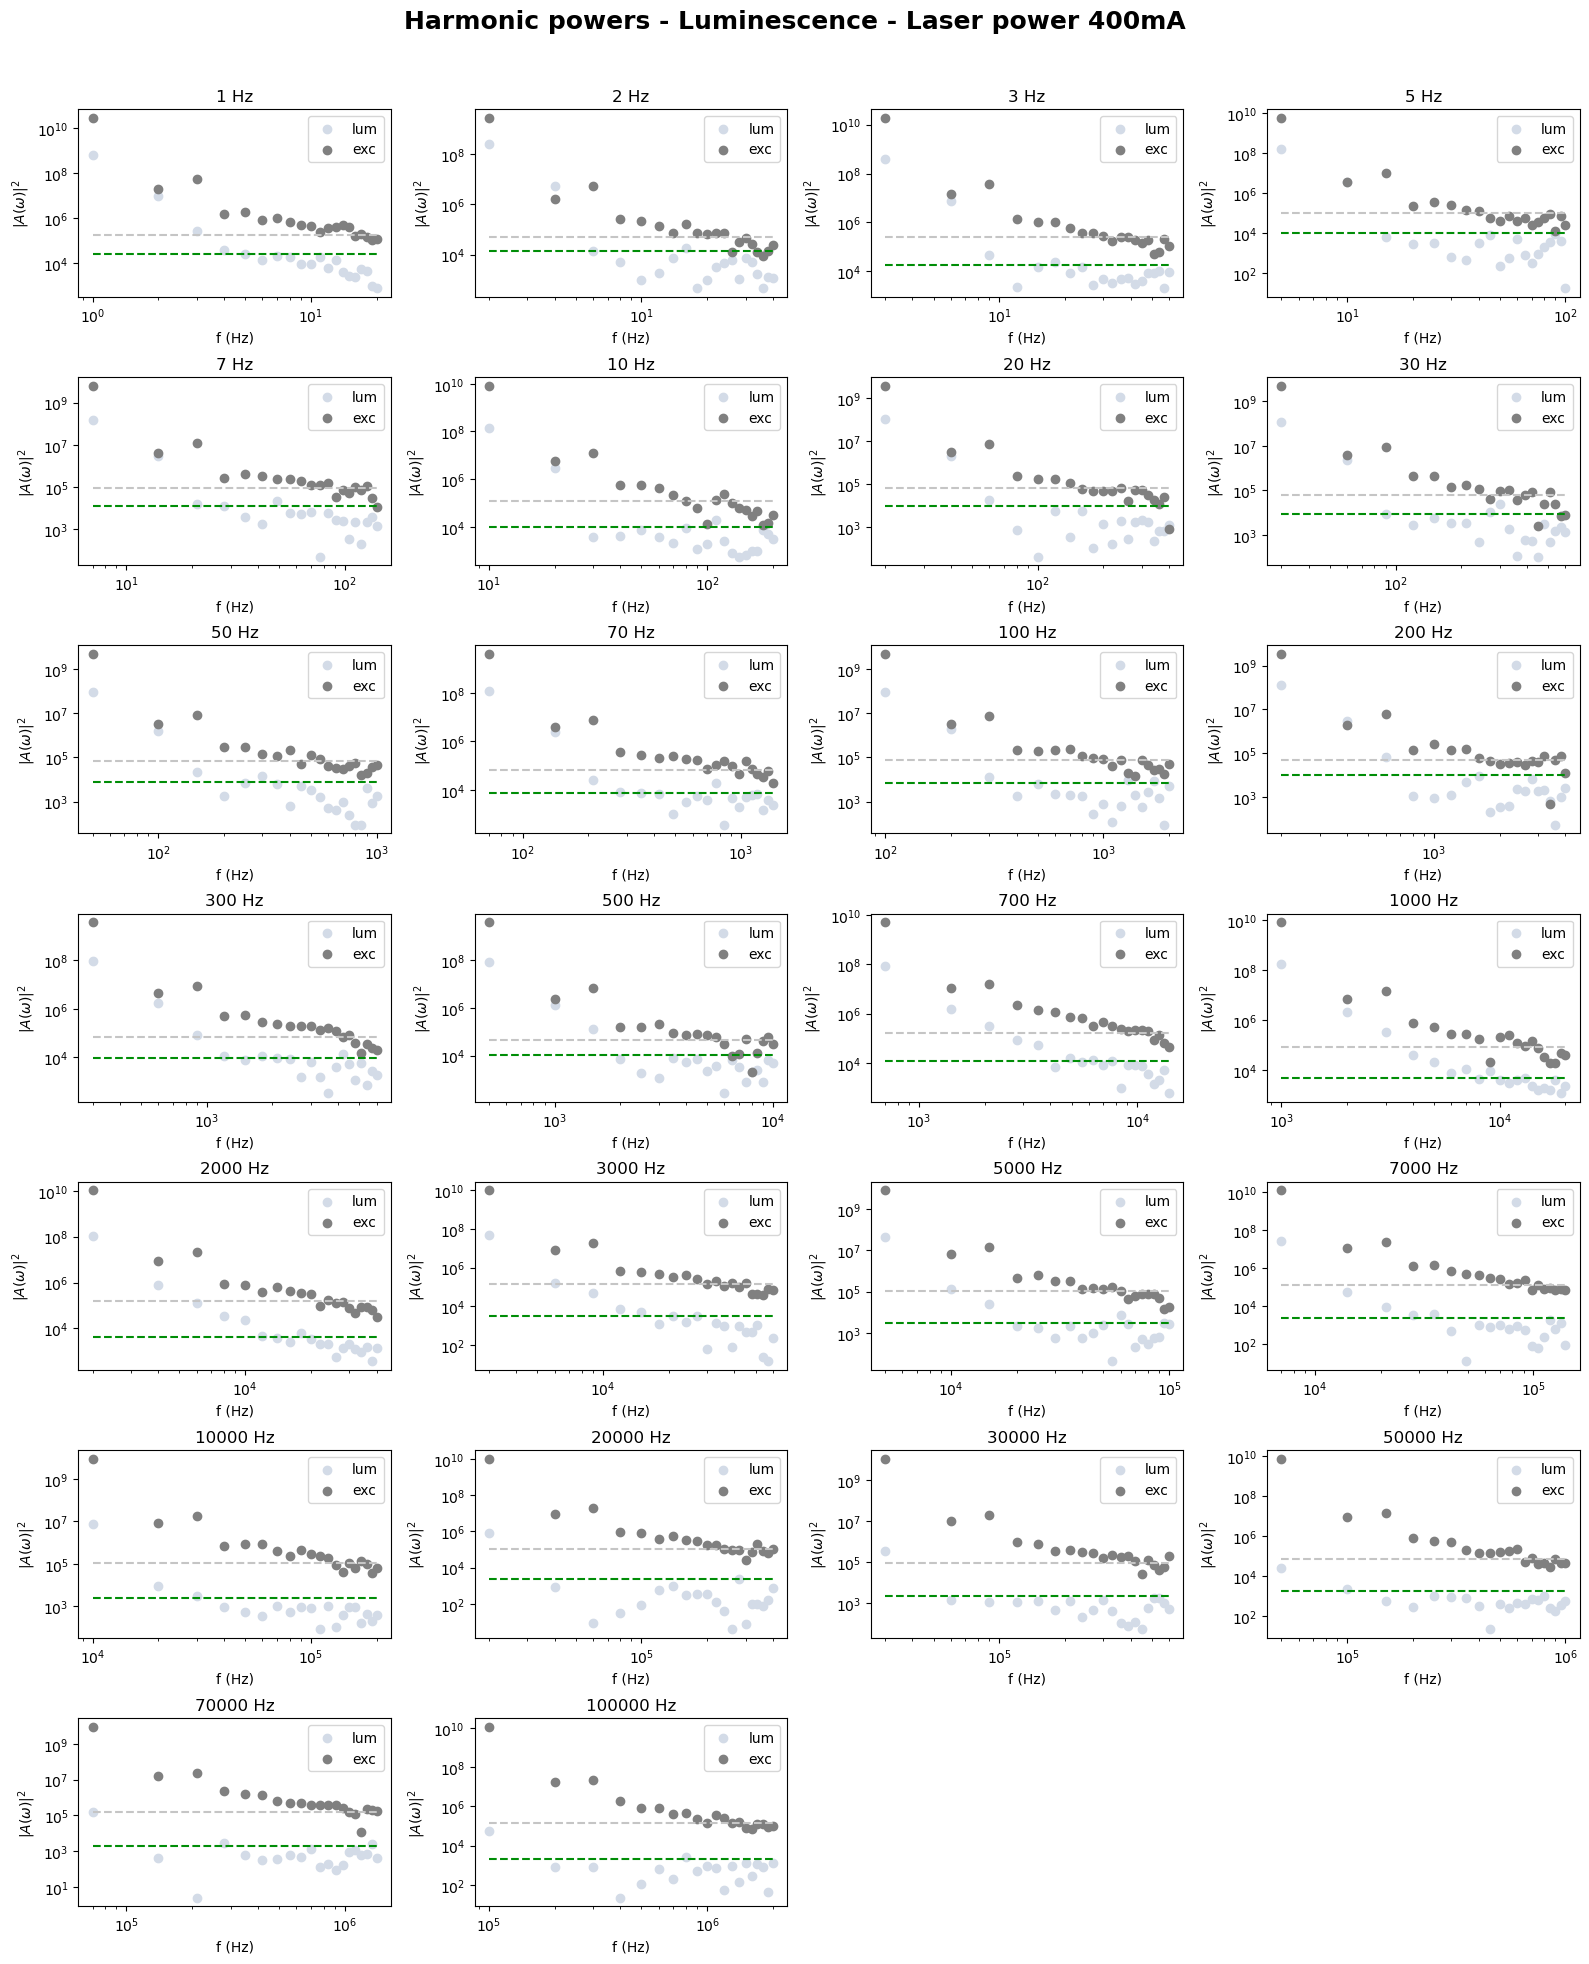

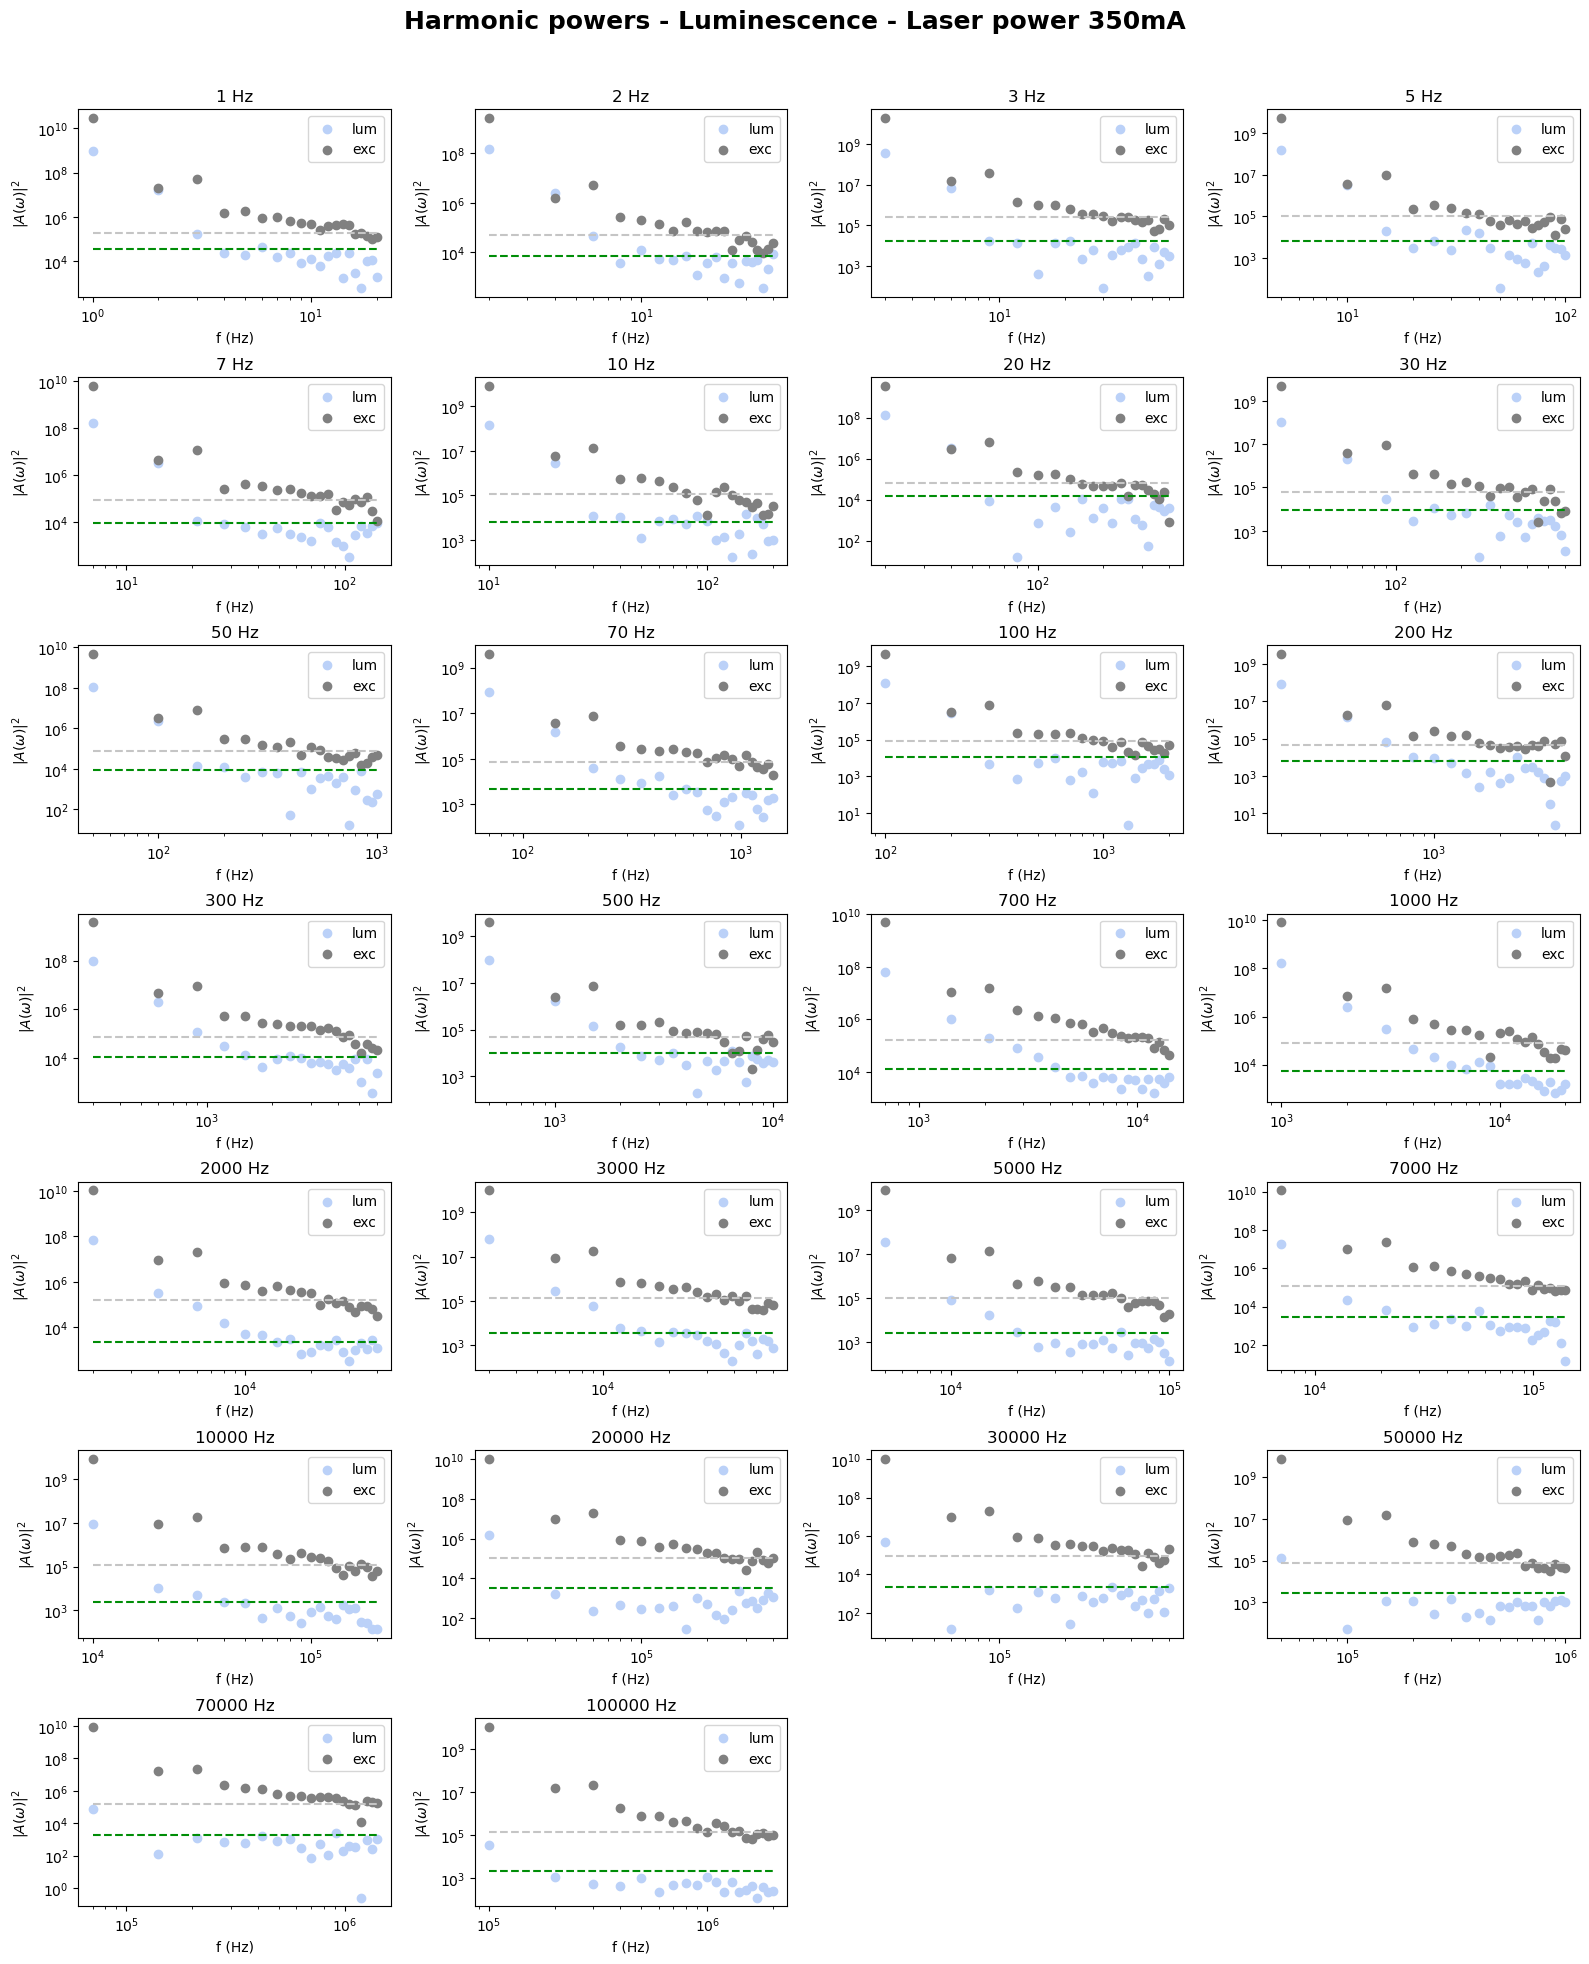

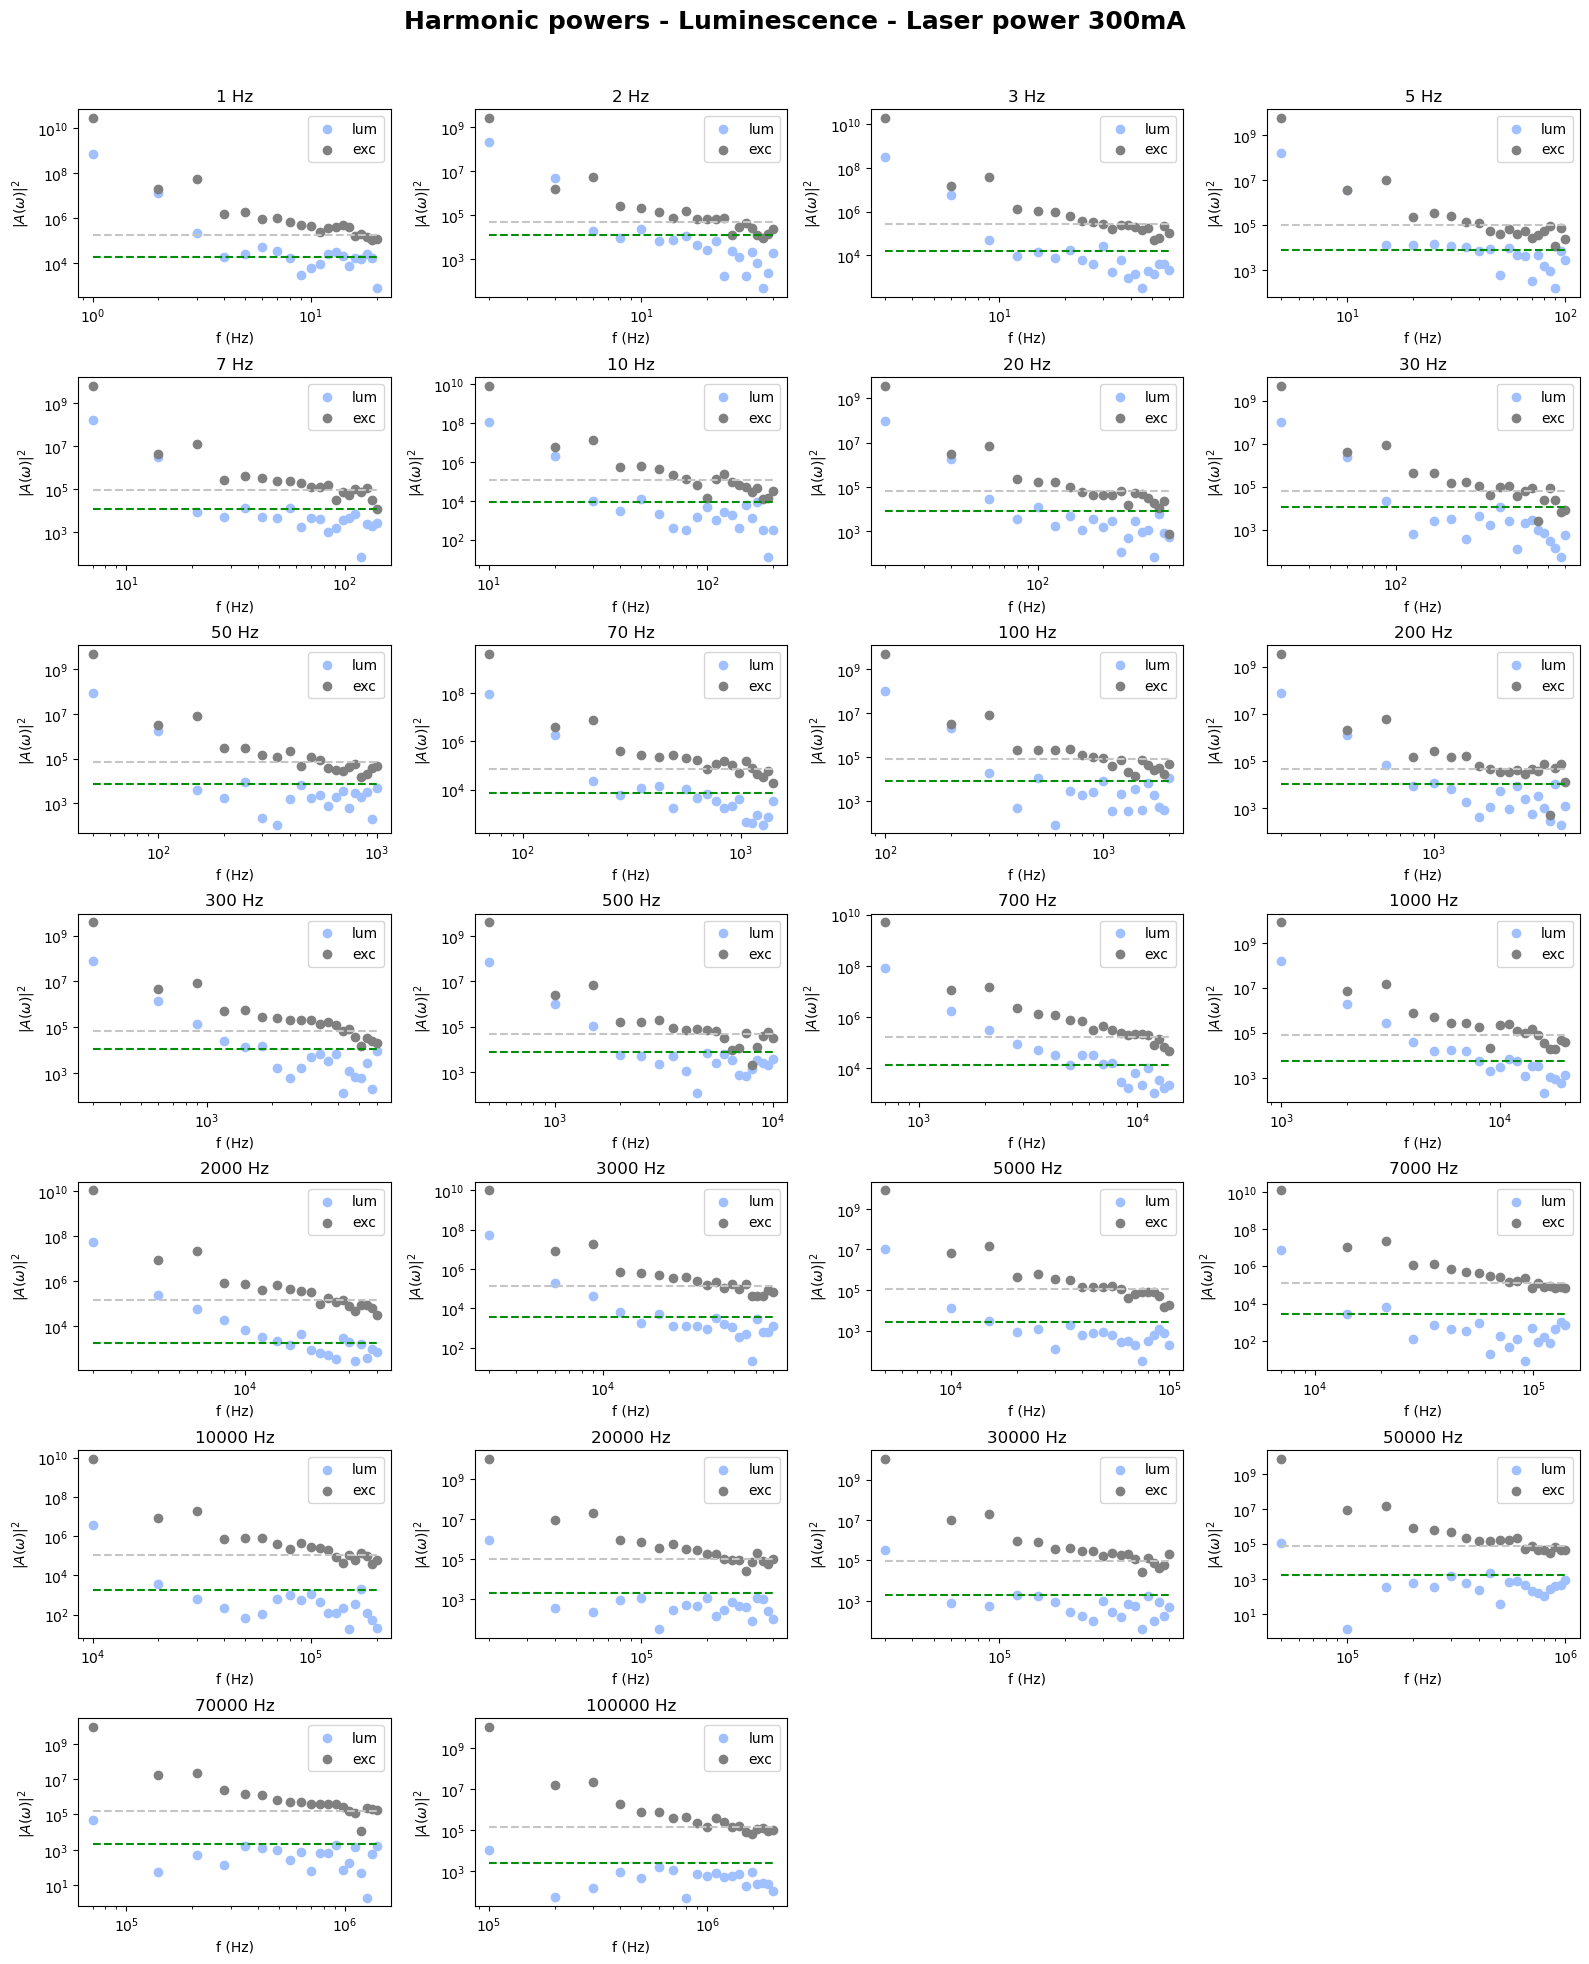

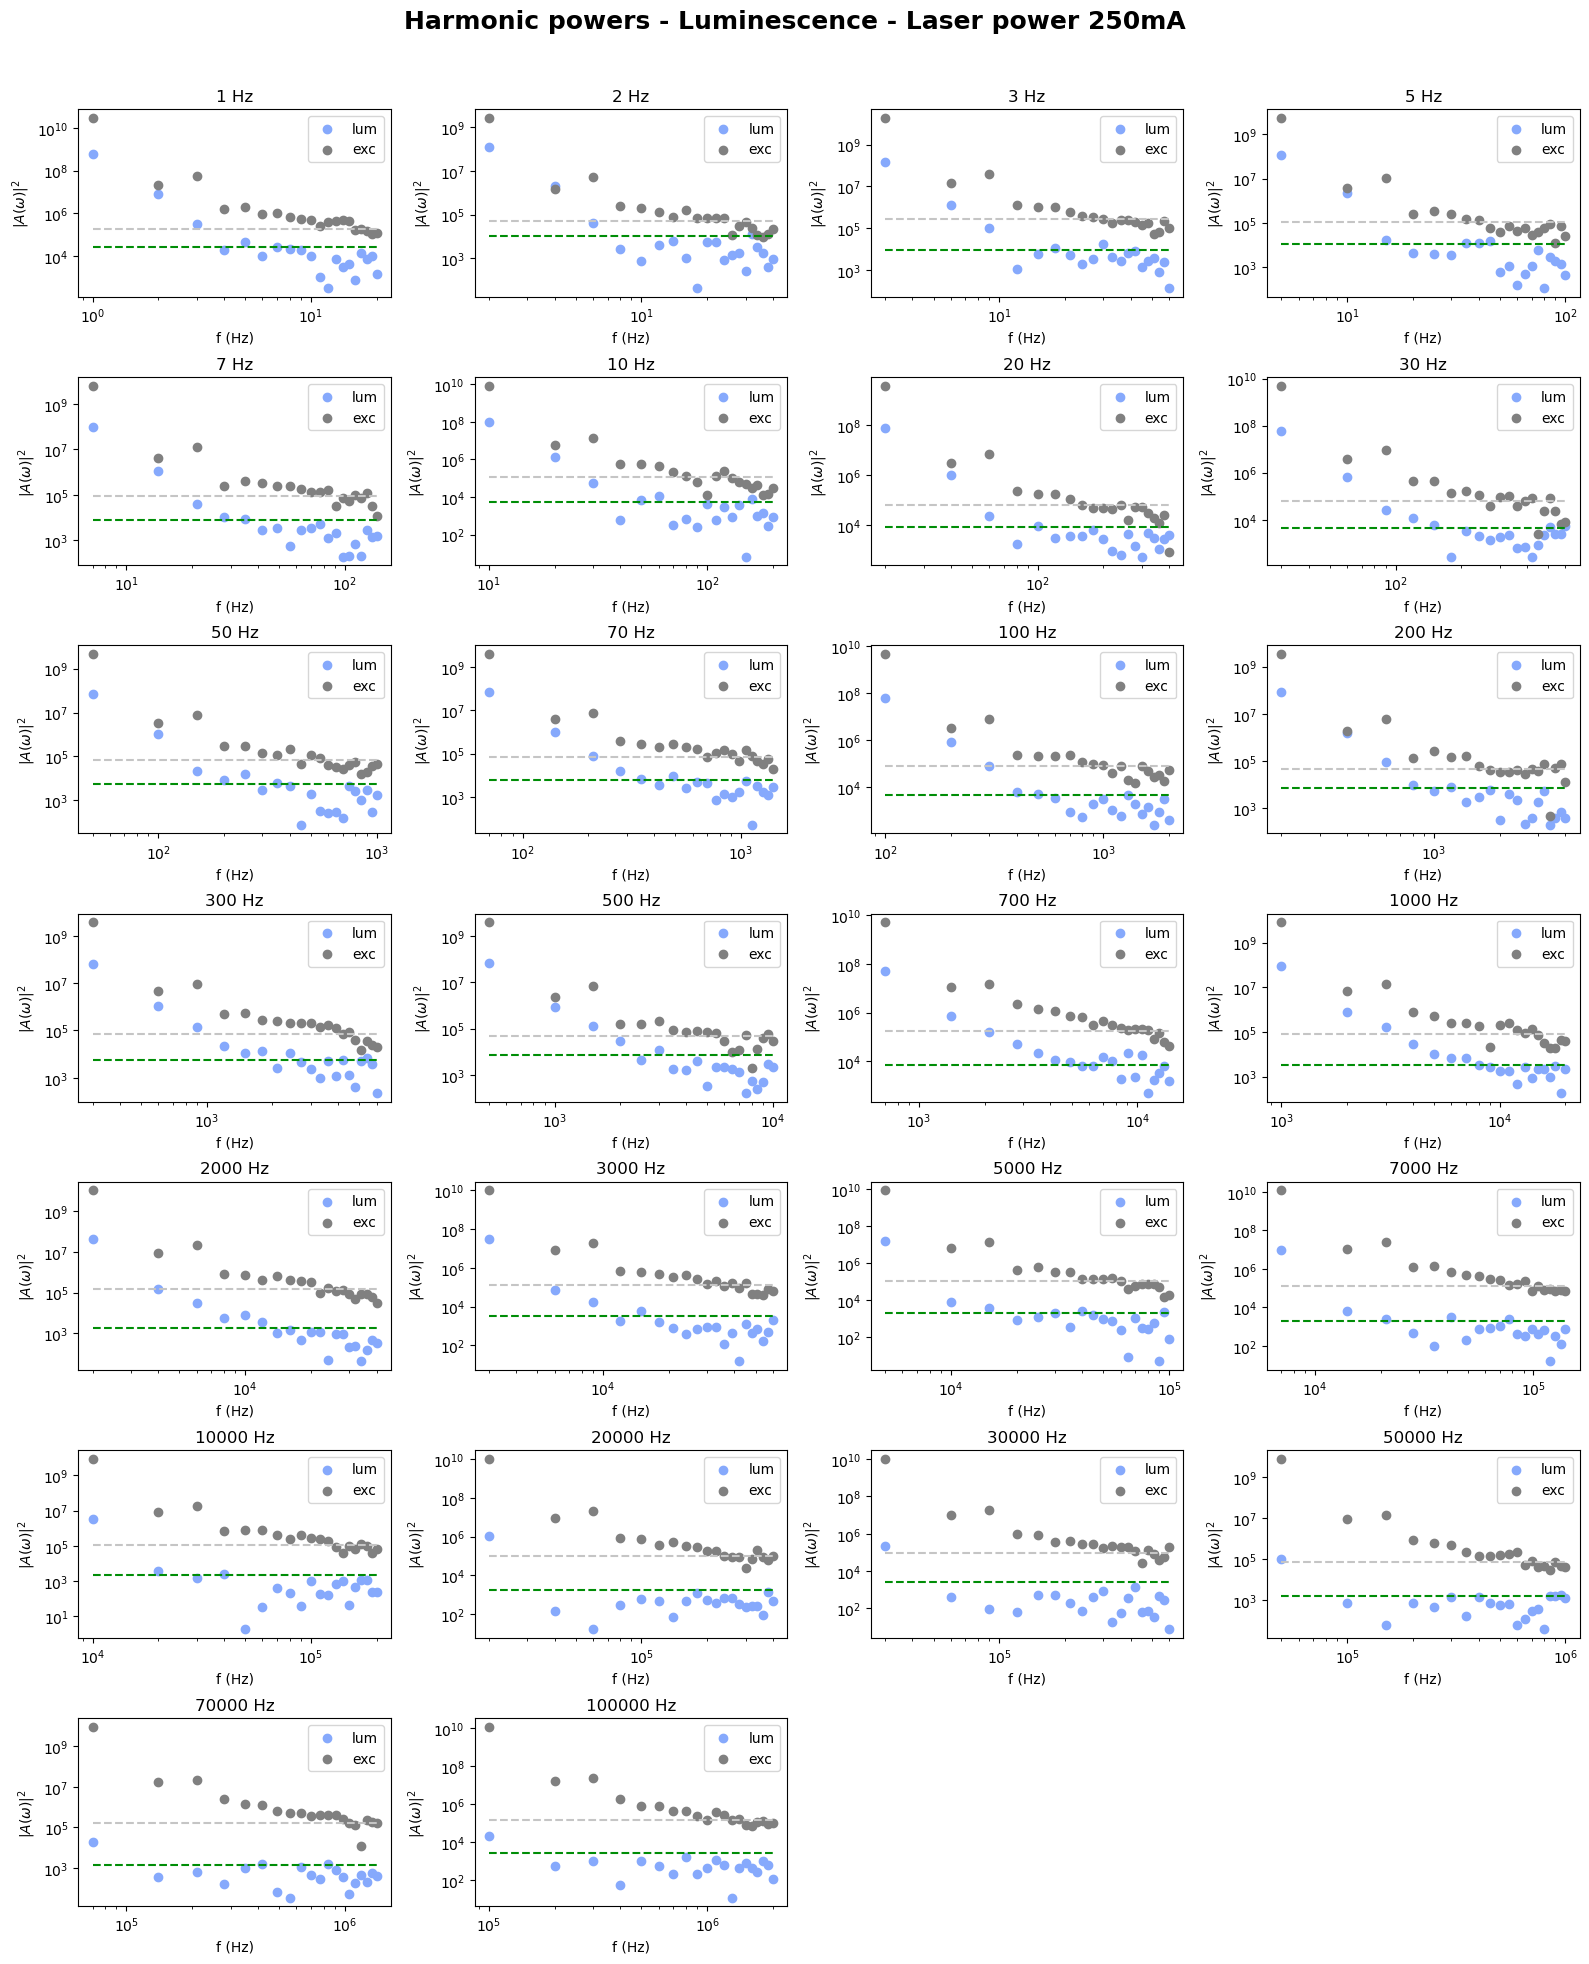

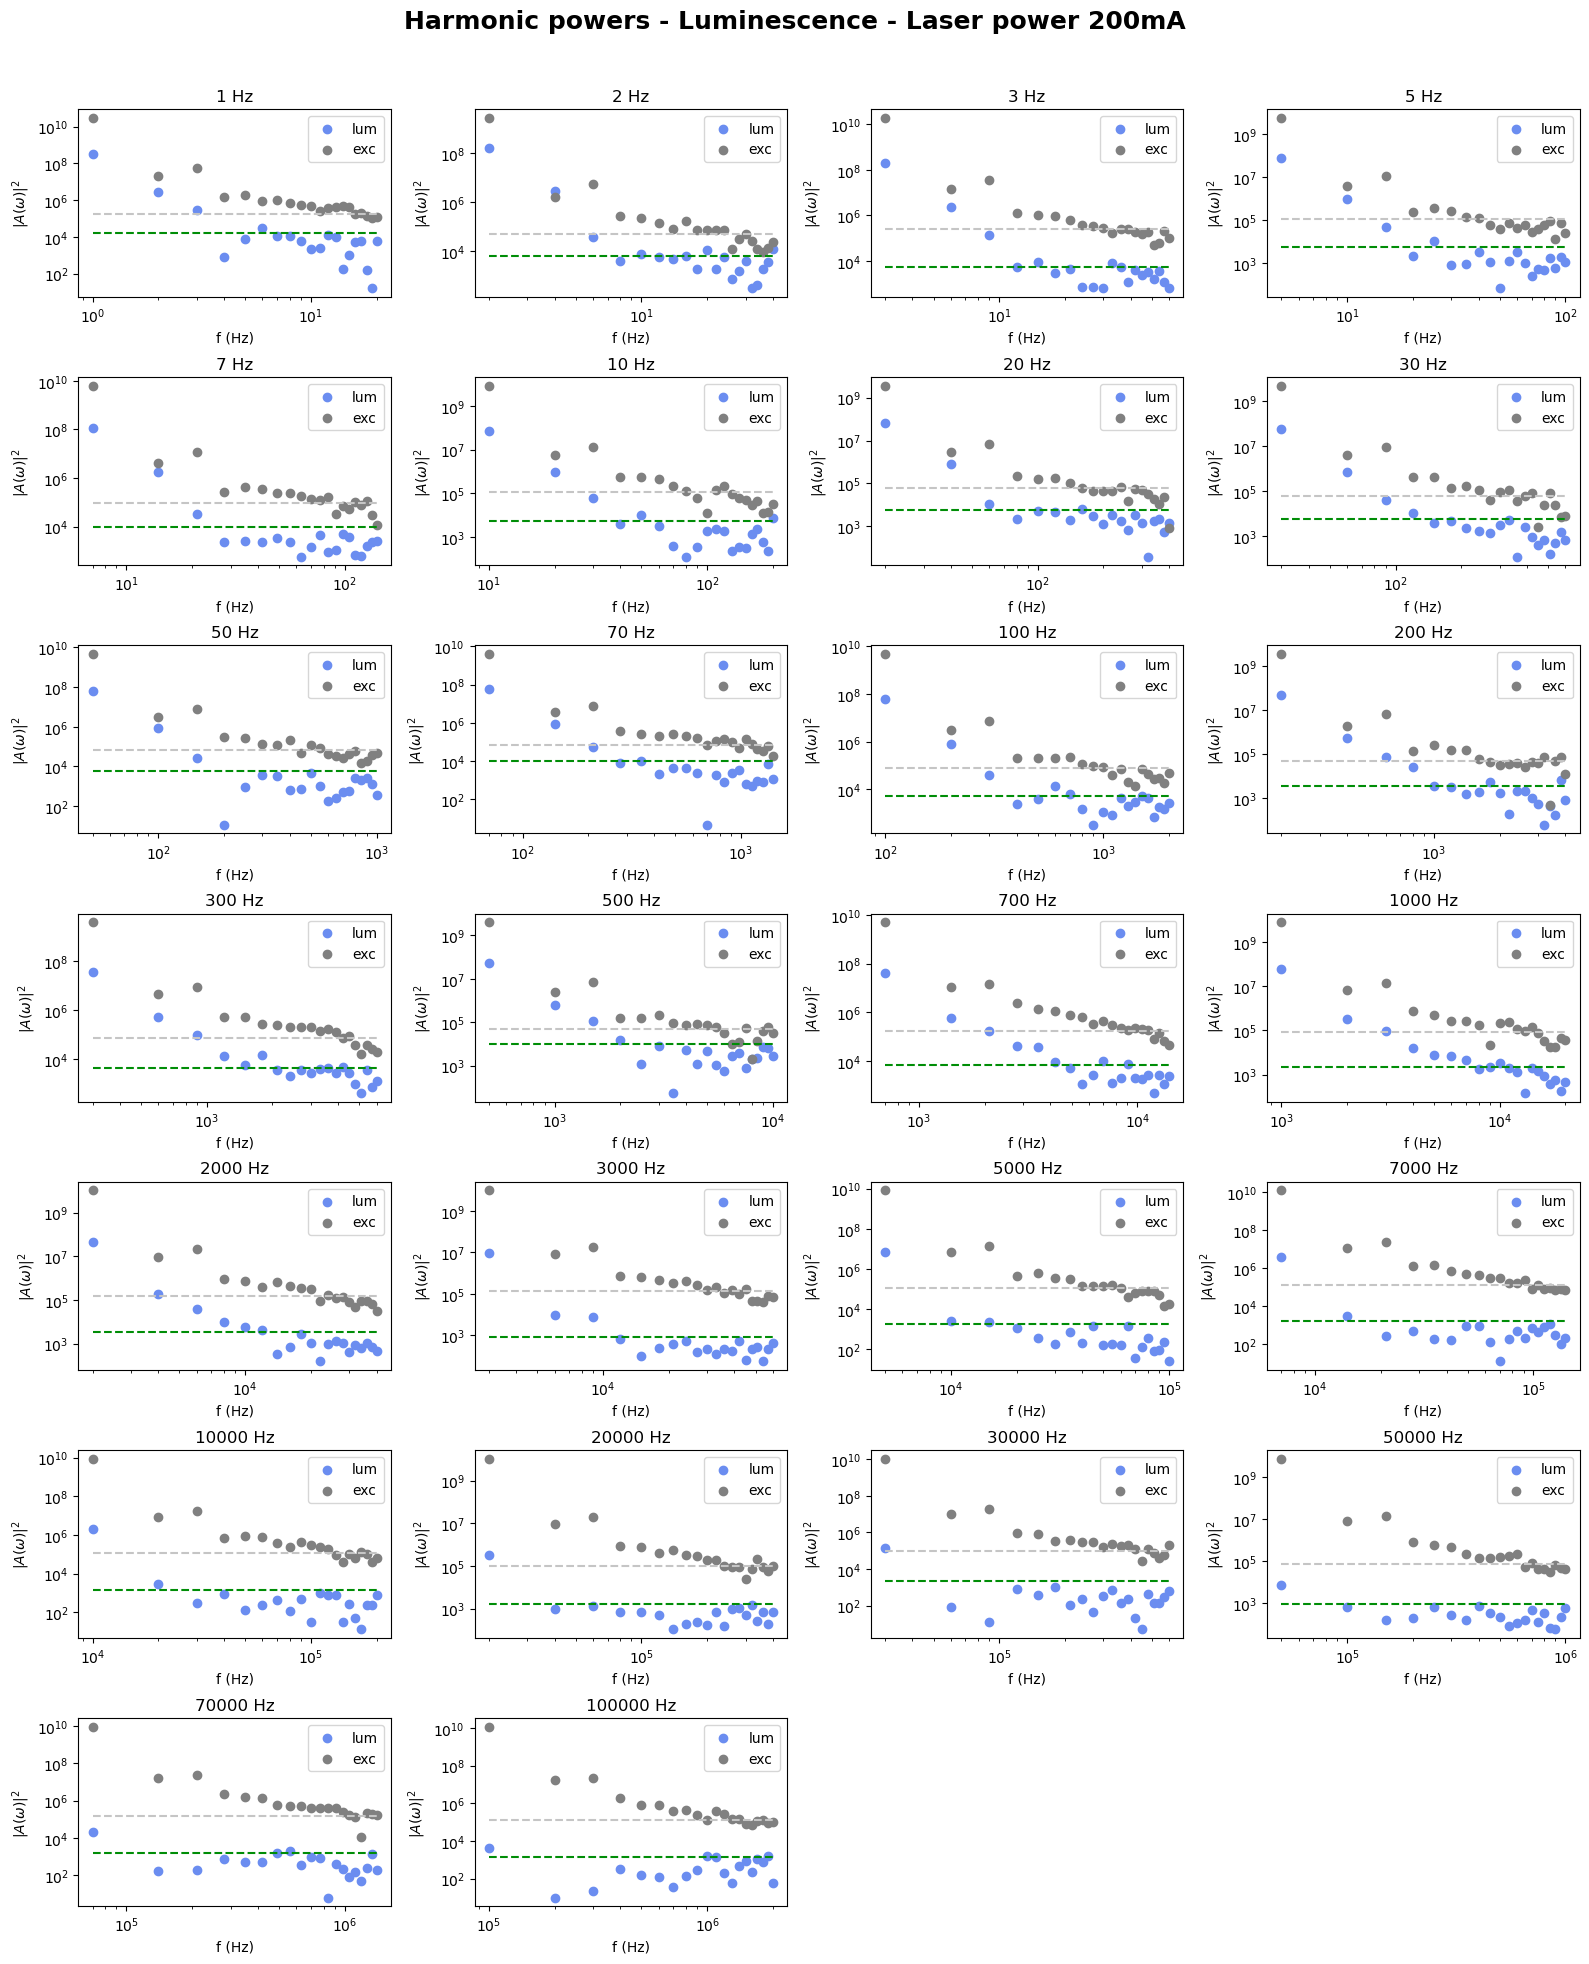

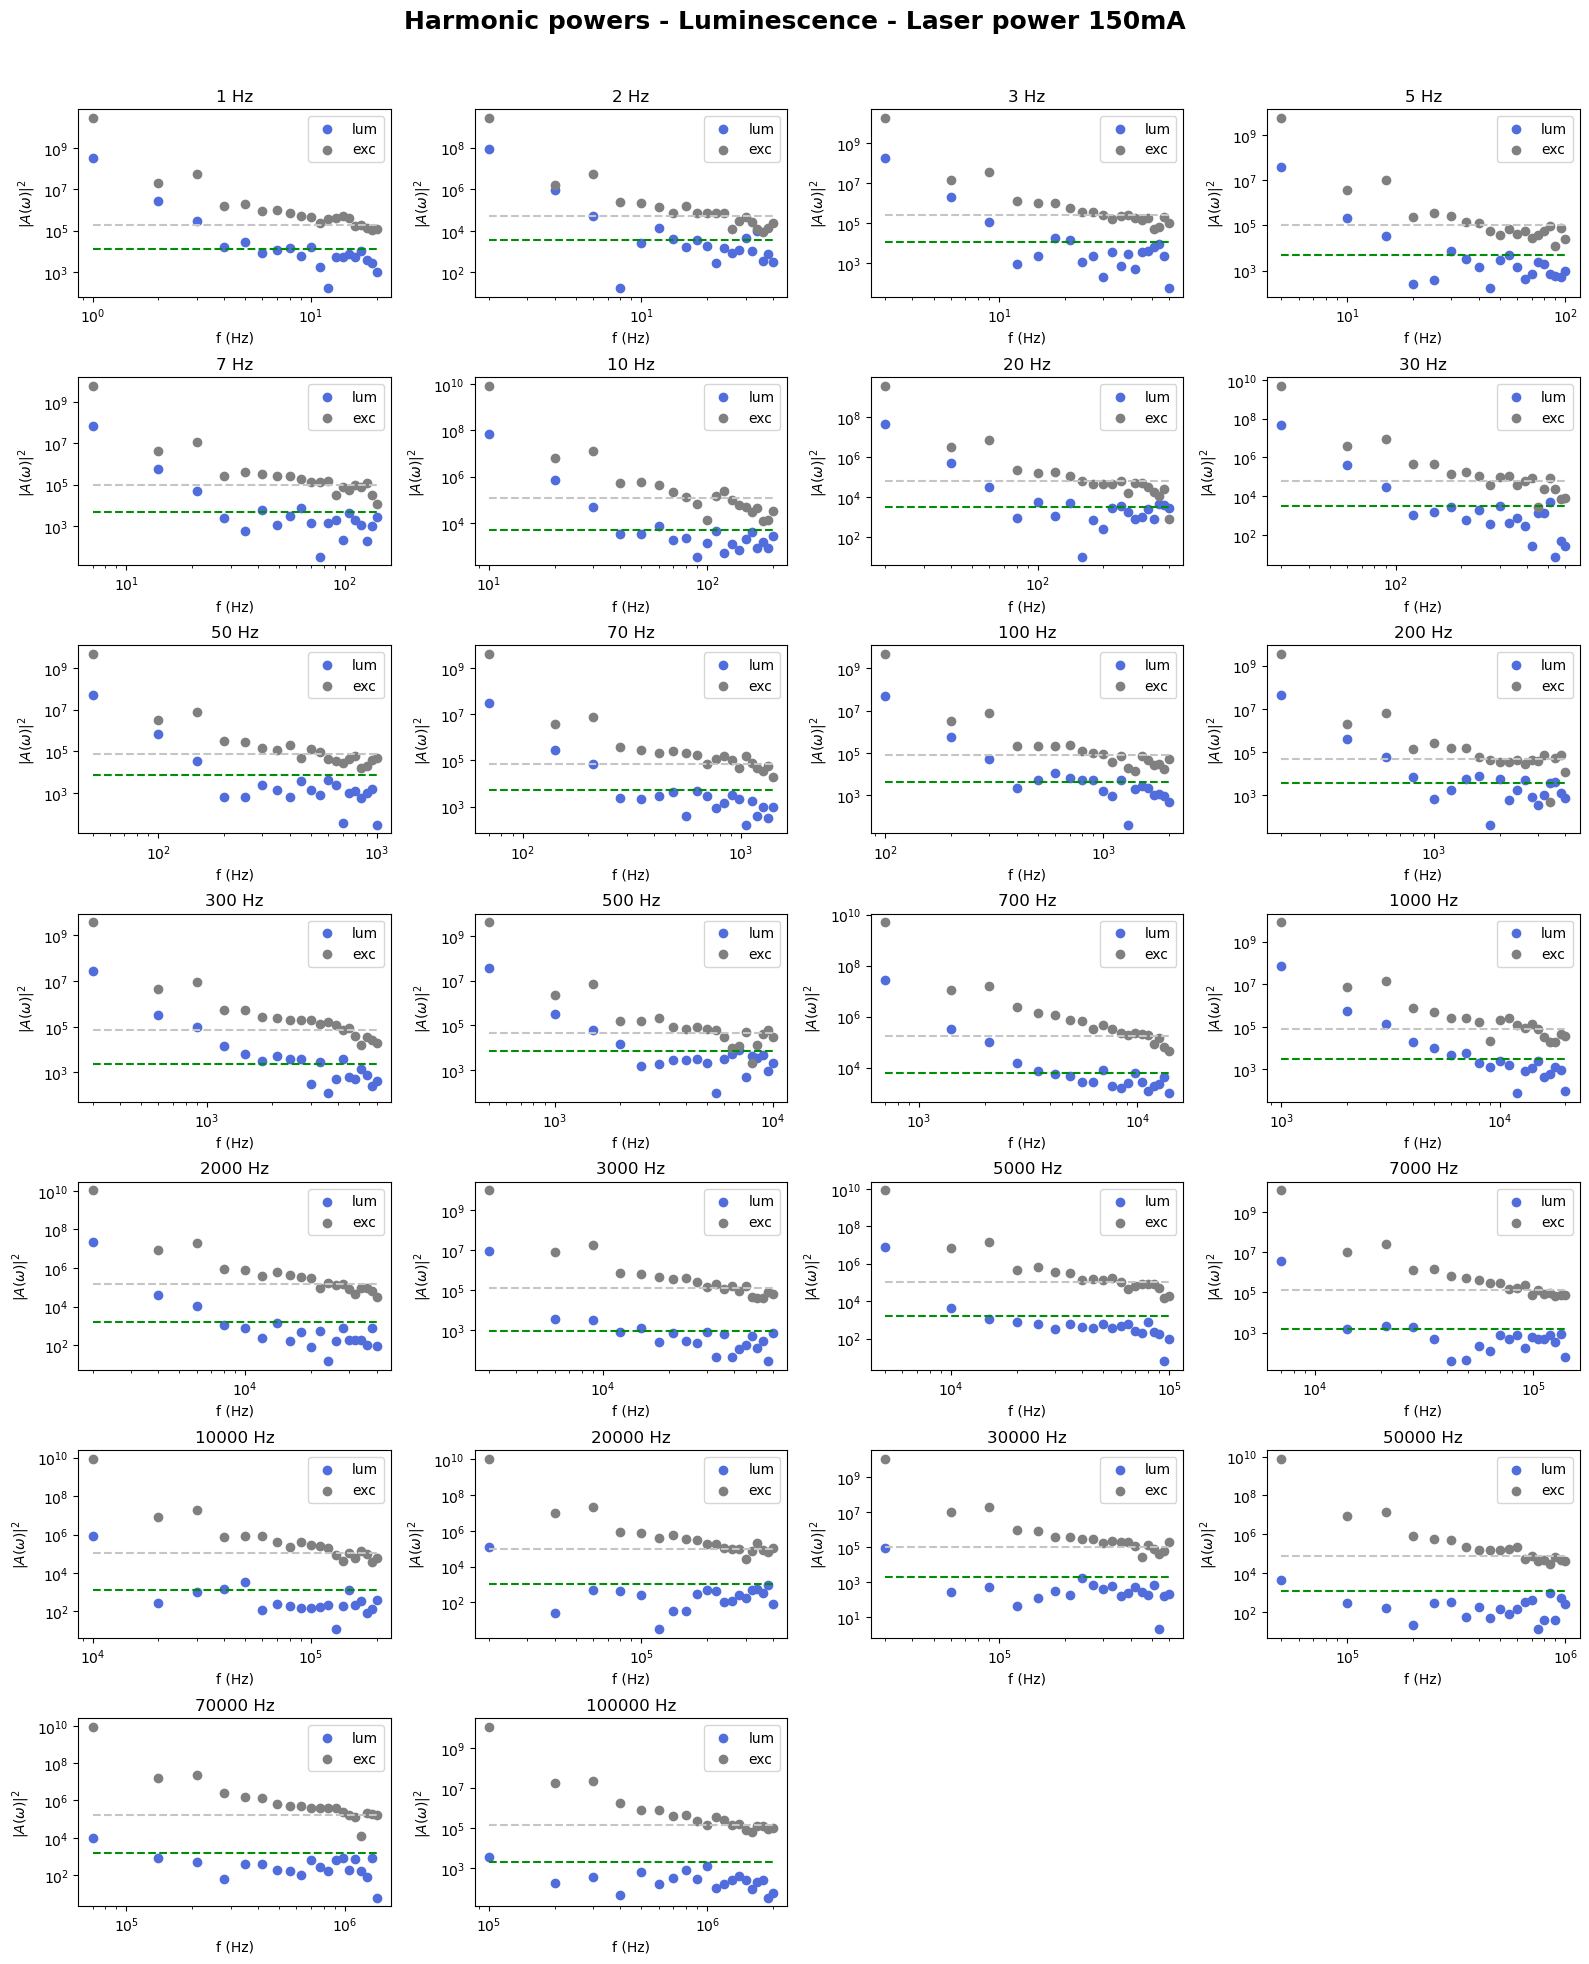

In [33]:
plot_harmonic_power(
    particles = p_list,
    # particles_off = [i for i in range(14) if i != 0 ],
    # freqs_off = [freq for freq in freq_list if freq != 1  ],
    power_label = power_label,
    laser_exc = exc_data_npy
    )

### Total Harmonic Distortion

A distorção harmônica total (THD) que apresentamos abaixo é definida da seguinte forma: 

A THD do harmônico $k$ até o harmônico $n$ é

\begin{equation}
THD_f = \frac{\sqrt{|A_k|^2+...+|A_n|^2}}{|A_1|}
\end{equation}
onde $A_j$ é a amplitude do j-ésimo harmônico.

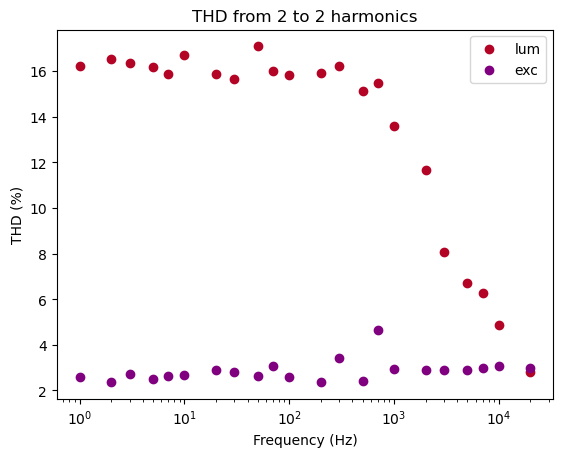

In [52]:
plot_thd(p_list, 
         particles_off = [i for i in range(num_particles) if i > 0], 
         freqs_off = [ freq for freq in freq_list if freq > 20000], 
         laser_data = exc_data_npy,
         num_harmonics = 2,
         )


Note que acima, na verdade temos a razão do módulo da amplitude do 2º harmônico e do fundamental, i. e., $|A_2|/|A_1|$.

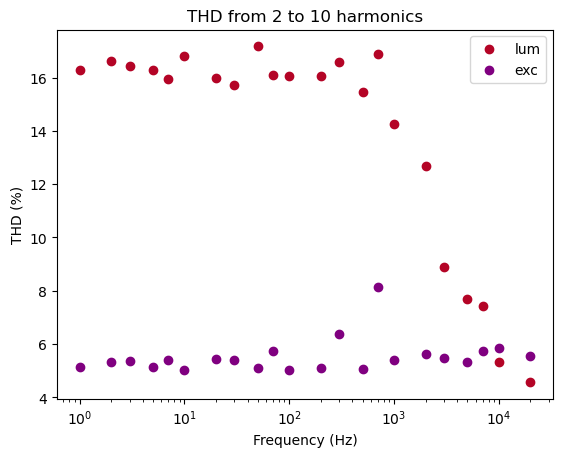

In [53]:
plot_thd(p_list, 
         particles_off = [i for i in range(num_particles) if i > 0], 
         freqs_off = [ freq for freq in freq_list if freq > 20000], 
         laser_data = exc_data_npy,
         num_harmonics = 10,
         )

Vemos acima que inserir mais harmônicos basicamente não altera o cenário. 

Agora vamos ver como fica se inserirmos todas as frequências medidas (1Hz até 100kHz) .
Segue o gráfico abaixo:

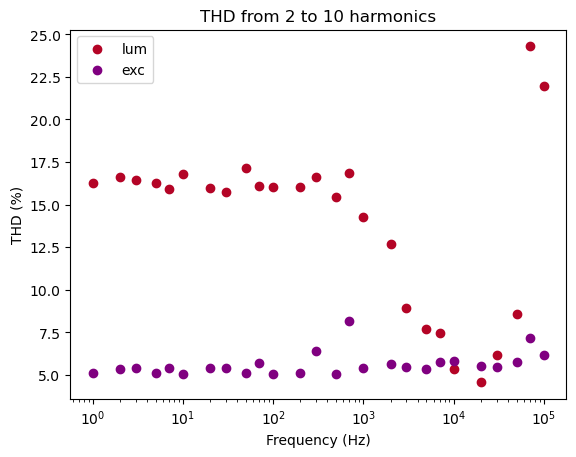

In [54]:
plot_thd(p_list, 
         particles_off = [i for i in range(num_particles) if i > 0], 
        #  freqs_off = [ freq for freq in freq_list if freq > 20000], 
         laser_data = exc_data_npy,
         num_harmonics = 10,
         )